# [7.5] Predictive Concept Decoders - Solutions

> **Claim.** A sparse concept bottleneck only earns the PCD name if concept-question interactions answer held-out behavioral questions better than question-agnostic probes, text/template shortcuts, shuffled-question, random-label, single-concept, and dense non-interaction controls, and if targeted concept removal beats a matched active-control removal.

Predictive Concept Decoders sit one level above ordinary probes. A probe asks one fixed question of an activation. A PCD receives an activation, maps it into a sparse concept bottleneck, and answers a natural-language behavioral question about that activation.

The standard for this notebook is deliberately unforgiving:

```text
activation -> sparse concepts -> question-specific concept slots -> answer logits
```

You will first build a planted toy world where the true sparse concepts are known exactly. Only after the toy controls behave correctly will you inspect the pinned `gelu-1l` evidence. The real-model section is honest about scope: it is a small surface-vs-motion preflight, not a broad PCD benchmark.


## Learning Objectives

By the end of this notebook, you will have shown that concept-question interaction slots answer held-out behavioral questions in an exact sparse-concept world, because they beat question-agnostic probes, text/template shortcuts, shuffled-question, random-label, single-concept, and dense non-interaction controls, and targeted concept removal beats a matched active-control removal.



By the end of this notebook, you should be able to:

- construct a planted sparse-concept world with exact hidden ground truth;
- keep activation rows, question ids, answer ids, and question text aligned;
- implement sparse concept encoding with threshold and top-k controls;
- implement concept-question interaction slots rather than an additive question embedding shortcut;
- train and evaluate a tiny question-conditioned decoder;
- reject weak PCD claims using six controls;
- make a concept-question heatmap, held-out prediction table, baseline bar chart, and removal chart;
- explain what the current `gelu-1l` evidence does and does not establish.


## Cold Open

Here is the failure mode this section is designed to catch.

Imagine a hidden state contains four planted concepts: `surface`, `motion`, `red`, and `animal`. We ask four questions, one per concept. If the same hidden state appears under all four questions, then a question-agnostic probe has contradictory labels for the same input row. A text/template baseline should also fail, because the toy prompts deliberately do not say which hidden concepts are active.

A PCD only wins if the question changes how sparse concepts are read. The signature result is a heatmap whose rows are questions and whose columns are concepts. The diagonal should light up; the nuisance/template concepts should stay dark.


In [1]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
import torch.nn.functional as F
from IPython.display import display

chapter = "chapter7_activation_to_language"
section = "part5_predictive_concept_decoders"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part5_predictive_concept_decoders.tests as tests

MAIN = __name__ == "__main__"
GT_TIER = "GT-3"
EXERCISE_ID = "7_5_predictive_concept_decoders"
EXPECTED_RUNTIME = "45-75 minutes; CPU exercises only in this notebook pass"
REQUIRES_GPU = False

PLANTED_PCD_QUESTIONS = (
    "Is the hidden surface concept active?",
    "Is the hidden motion concept active?",
    "Is the hidden red concept active?",
    "Is the hidden animal concept active?",
)
PLANTED_CONCEPT_NAMES = (
    "surface",
    "motion",
    "red",
    "animal",
    "template_alpha",
    "template_beta",
)
PLANTED_QUESTION_TO_CONCEPT = (0, 1, 2, 3)


# Pinned safe prompts used only to render the committed real-model evidence.
TL_EVAL_EXAMPLES = [
    ("Yesterday at home, the blanket lay on the", "surface"),
    ("In the quiet room, the lamp sat on the", "surface"),
    ("After dinner, the pillow rested on the", "surface"),
    ("Near the window, the chair sat on the", "surface"),
    ("At noon outside, the rocket launched into the", "motion"),
    ("During the game, the ball flew over the", "motion"),
    ("On the hill, the kite floated above the", "motion"),
    ("In the hallway, the train rushed through the", "motion"),
]
TL_PCD_QUESTIONS = (
    "Will the next token be the surface-associated token?",
    "Will the next token be the motion-associated token?",
    "Is the hidden state carrying a resting-surface concept?",
    "Is the hidden state carrying a motion-or-airborne concept?",
)


### Exercise - build an exact planted sparse-concept world

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend 10-15 minutes on this exercise.
> ```

We need a toy world where ground truth is not a vibe. Each example has hidden binary concepts. Activations are dense-looking vectors, but the planted concept directions recover those concepts exactly. The prompt text is intentionally uninformative, so text/template shortcuts cannot solve the task.

<details>
<summary>Expected output</summary>

```text
All tests in `test_make_planted_pcd_world_has_exact_sparse_ground_truth` passed!
```

The world should contain 32 train examples, 32 held-out examples, 6 concept columns, and 4 behavioral questions.

</details>

<details>
<summary>Help - how can dense activations have exact concepts?</summary>

Use an orthonormal basis. Put the sparse concept vector into the first concept directions, then add small nuisance features in orthogonal null directions. Projecting back onto the concept directions recovers the sparse concepts because the null directions are orthogonal.

</details>

<details>
<summary>Interpretation</summary>

This is the ground-truth contract. Later, when the PCD wins, you know it wins because it used the right sparse variables, not because an activation report happened to be green.

</details>

<details>
<summary>Solution</summary>

```python
def _dense_orthonormal_columns(
    *,
    d_model: int,
    columns: int,
    seed: int,
) -> t.Tensor:
    if d_model < columns:
        raise ValueError("d_model must be at least as large as the requested column count.")
    generator = t.Generator(device="cpu").manual_seed(seed)
    matrix = t.randn(d_model, d_model, generator=generator)
    q, _r = t.linalg.qr(matrix)
    return q[:, :columns].float()


def make_planted_pcd_world(
    *,
    seed: int = 0,
    d_model: int = 12,
) -> PlantedPCDWorld:
    """Create an exact sparse-concept world with dense-looking activations."""

    question_count = len(PLANTED_PCD_QUESTIONS)
    target_concept_count = len(PLANTED_QUESTION_TO_CONCEPT)
    concept_count = len(PLANTED_CONCEPT_NAMES)
    if d_model < concept_count + 2:
        raise ValueError("d_model must leave room for planted concepts and null directions.")

    rows = []
    for index in range(2**target_concept_count):
        rows.append([(index >> bit) & 1 for bit in range(target_concept_count)])
    base_targets = t.tensor(rows, dtype=t.float32).repeat_interleave(2, dim=0)
    replicate_ids = t.arange(base_targets.shape[0]) % 2

    concept_basis = _dense_orthonormal_columns(
        d_model=d_model,
        columns=concept_count + 2,
        seed=seed,
    )
    concept_directions = concept_basis[:, :concept_count]
    null_directions = concept_basis[:, concept_count : concept_count + 2]

    def build_split(split_name: str, offset: int) -> tuple[t.Tensor, t.Tensor, t.Tensor, tuple[str, ...]]:
        template_ids = (replicate_ids + offset) % question_count
        nuisance = t.stack(
            [
                replicate_ids.float(),
                1.0 - replicate_ids.float(),
            ],
            dim=1,
        )
        concepts = t.cat([base_targets, nuisance], dim=1)
        null_features = t.stack(
            [
                ((t.arange(base_targets.shape[0]) + offset) % 5).float() / 10.0,
                ((t.arange(base_targets.shape[0]) * 2 + offset) % 7).float() / 10.0,
            ],
            dim=1,
        )
        activations = concepts @ concept_directions.T + 0.1 * null_features @ null_directions.T
        prompts = tuple(
            f"{split_name} latent card {i:02d} / template {int(template_id.item())}"
            for i, template_id in enumerate(template_ids)
        )
        return activations.float(), concepts.float(), template_ids.long(), prompts

    train_activations, train_concepts, train_templates, train_prompts = build_split(
        "train",
        offset=0,
    )
    heldout_activations, heldout_concepts, heldout_templates, heldout_prompts = build_split(
        "heldout",
        offset=1,
    )

    recovered_train = train_activations @ concept_directions
    recovered_heldout = heldout_activations @ concept_directions
    if not t.allclose(recovered_train, train_concepts, atol=1e-5, rtol=1e-5):
        raise RuntimeError("planted train concepts are not exactly recoverable.")
    if not t.allclose(recovered_heldout, heldout_concepts, atol=1e-5, rtol=1e-5):
        raise RuntimeError("planted held-out concepts are not exactly recoverable.")

    return PlantedPCDWorld(
        train_activations=train_activations,
        heldout_activations=heldout_activations,
        train_true_concepts=train_concepts,
        heldout_true_concepts=heldout_concepts,
        concept_directions=concept_directions,
        train_template_ids=train_templates,
        heldout_template_ids=heldout_templates,
        question_texts=PLANTED_PCD_QUESTIONS,
        concept_names=PLANTED_CONCEPT_NAMES,
        train_prompts=train_prompts,
        heldout_prompts=heldout_prompts,
    )
```

</details>


In [2]:
@dataclass(frozen=True)
class PlantedPCDWorld:
    train_activations: t.Tensor
    heldout_activations: t.Tensor
    train_true_concepts: t.Tensor
    heldout_true_concepts: t.Tensor
    concept_directions: t.Tensor
    train_template_ids: t.Tensor
    heldout_template_ids: t.Tensor
    question_texts: tuple[str, ...]
    concept_names: tuple[str, ...]
    train_prompts: tuple[str, ...]
    heldout_prompts: tuple[str, ...]


def _dense_orthonormal_columns(
    *,
    d_model: int,
    columns: int,
    seed: int,
) -> t.Tensor:
    if d_model < columns:
        raise ValueError("d_model must be at least as large as the requested column count.")
    generator = t.Generator(device="cpu").manual_seed(seed)
    matrix = t.randn(d_model, d_model, generator=generator)
    q, _r = t.linalg.qr(matrix)
    return q[:, :columns].float()


def make_planted_pcd_world(
    *,
    seed: int = 0,
    d_model: int = 12,
) -> PlantedPCDWorld:
    """Create an exact sparse-concept world with dense-looking activations."""

    question_count = len(PLANTED_PCD_QUESTIONS)
    target_concept_count = len(PLANTED_QUESTION_TO_CONCEPT)
    concept_count = len(PLANTED_CONCEPT_NAMES)
    if d_model < concept_count + 2:
        raise ValueError("d_model must leave room for planted concepts and null directions.")

    rows = []
    for index in range(2**target_concept_count):
        rows.append([(index >> bit) & 1 for bit in range(target_concept_count)])
    base_targets = t.tensor(rows, dtype=t.float32).repeat_interleave(2, dim=0)
    replicate_ids = t.arange(base_targets.shape[0]) % 2

    concept_basis = _dense_orthonormal_columns(
        d_model=d_model,
        columns=concept_count + 2,
        seed=seed,
    )
    concept_directions = concept_basis[:, :concept_count]
    null_directions = concept_basis[:, concept_count : concept_count + 2]

    def build_split(split_name: str, offset: int) -> tuple[t.Tensor, t.Tensor, t.Tensor, tuple[str, ...]]:
        template_ids = (replicate_ids + offset) % question_count
        nuisance = t.stack(
            [
                replicate_ids.float(),
                1.0 - replicate_ids.float(),
            ],
            dim=1,
        )
        concepts = t.cat([base_targets, nuisance], dim=1)
        null_features = t.stack(
            [
                ((t.arange(base_targets.shape[0]) + offset) % 5).float() / 10.0,
                ((t.arange(base_targets.shape[0]) * 2 + offset) % 7).float() / 10.0,
            ],
            dim=1,
        )
        activations = concepts @ concept_directions.T + 0.1 * null_features @ null_directions.T
        prompts = tuple(
            f"{split_name} latent card {i:02d} / template {int(template_id.item())}"
            for i, template_id in enumerate(template_ids)
        )
        return activations.float(), concepts.float(), template_ids.long(), prompts

    train_activations, train_concepts, train_templates, train_prompts = build_split(
        "train",
        offset=0,
    )
    heldout_activations, heldout_concepts, heldout_templates, heldout_prompts = build_split(
        "heldout",
        offset=1,
    )

    recovered_train = train_activations @ concept_directions
    recovered_heldout = heldout_activations @ concept_directions
    if not t.allclose(recovered_train, train_concepts, atol=1e-5, rtol=1e-5):
        raise RuntimeError("planted train concepts are not exactly recoverable.")
    if not t.allclose(recovered_heldout, heldout_concepts, atol=1e-5, rtol=1e-5):
        raise RuntimeError("planted held-out concepts are not exactly recoverable.")

    return PlantedPCDWorld(
        train_activations=train_activations,
        heldout_activations=heldout_activations,
        train_true_concepts=train_concepts,
        heldout_true_concepts=heldout_concepts,
        concept_directions=concept_directions,
        train_template_ids=train_templates,
        heldout_template_ids=heldout_templates,
        question_texts=PLANTED_PCD_QUESTIONS,
        concept_names=PLANTED_CONCEPT_NAMES,
        train_prompts=train_prompts,
        heldout_prompts=heldout_prompts,
    )


tests.test_make_planted_pcd_world_has_exact_sparse_ground_truth(make_planted_pcd_world)


All tests in `test_make_planted_pcd_world_has_exact_sparse_ground_truth` passed!


### Exercise - align activations, questions, and answers

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend 10 minutes on this exercise.
> ```

A PCD row is not just an activation. It is `(activation, question, answer)`. The same activation will appear four times, once for each behavioral question, and the answer changes with the question.

<details>
<summary>Expected output</summary>

```text
All tests in `test_build_pcd_question_batch_validates_shapes_and_questions` passed!
All tests in `test_build_pcd_question_batch_rejects_empty_and_bad_question_ids` passed!
All tests in `test_build_planted_question_rows_aligns_every_question` passed!
```

For 32 held-out activations and 4 questions, you should create 128 question rows.

</details>

<details>
<summary>Help - why repeat the same concept row?</summary>

Repeating the concept row under different questions creates the contradiction that defeats question-agnostic probes. A model that ignores the question sees identical inputs with different labels.

</details>

<details>
<summary>Interpretation</summary>

If this row alignment is wrong, every later metric is meaningless. This is why the tests check shape, nonempty batches, question-id range, and balanced answers.

</details>

<details>
<summary>Solution</summary>

```python
def default_pcd_questions() -> tuple[str, ...]:
    """Return the standard mini PCD behavioral question bank."""

    return (
        "Will the model answer Paris?",
        "Will the model refuse?",
        "Will the next token be a number?",
        "Is the hidden variable even?",
    )


def build_pcd_question_batch(
    activations: t.Tensor,
    question_ids: t.Tensor,
    answer_ids: t.Tensor,
    question_texts: tuple[str, ...] | None = None,
) -> PCDQuestionBatch:
    """Bundle activations with question ids, binary answers, and question text."""

    if activations.ndim != 2:
        raise ValueError("activations must have shape (examples, d_model).")
    if activations.shape[0] == 0:
        raise ValueError("activations must contain at least one example.")
    expected_shape = (activations.shape[0],)
    if question_ids.shape != expected_shape:
        raise ValueError("question_ids must have shape (examples,).")
    if answer_ids.shape != expected_shape:
        raise ValueError("answer_ids must have shape (examples,).")
    if question_texts is None:
        question_texts = default_pcd_questions()
    if not question_texts:
        raise ValueError("question_texts must be nonempty.")
    if int(question_ids.min().item()) < 0 or int(question_ids.max().item()) >= len(question_texts):
        raise ValueError("question_ids must index question_texts.")
    return PCDQuestionBatch(
        activations=activations,
        question_ids=question_ids.long(),
        answer_ids=answer_ids.long(),
        question_texts=question_texts,
    )


def build_planted_question_rows(
    concepts: t.Tensor,
    *,
    question_to_concept: tuple[int, ...] = PLANTED_QUESTION_TO_CONCEPT,
) -> tuple[t.Tensor, t.Tensor, t.Tensor, t.Tensor]:
    """Repeat concept rows under each question and label with the planted answer."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if len(question_to_concept) == 0:
        raise ValueError("question_to_concept must be nonempty.")
    if min(question_to_concept) < 0 or max(question_to_concept) >= concepts.shape[1]:
        raise ValueError("question_to_concept must index concept columns.")

    question_count = len(question_to_concept)
    row_concepts = concepts.repeat_interleave(question_count, dim=0).float()
    question_ids = t.arange(question_count, device=concepts.device).repeat(concepts.shape[0])
    question_embeddings = t.eye(question_count, device=concepts.device).repeat(concepts.shape[0], 1)
    answer_matrix = concepts[:, list(question_to_concept)].round().long().clamp(0, 1)
    answer_ids = answer_matrix.reshape(-1)
    return row_concepts, question_embeddings, question_ids.long(), answer_ids.long()
```

</details>


In [3]:
@dataclass(frozen=True)
class PCDQuestionBatch:
    activations: t.Tensor
    question_ids: t.Tensor
    answer_ids: t.Tensor
    question_texts: tuple[str, ...]


def default_pcd_questions() -> tuple[str, ...]:
    """Return the standard mini PCD behavioral question bank."""

    return (
        "Will the model answer Paris?",
        "Will the model refuse?",
        "Will the next token be a number?",
        "Is the hidden variable even?",
    )


def build_pcd_question_batch(
    activations: t.Tensor,
    question_ids: t.Tensor,
    answer_ids: t.Tensor,
    question_texts: tuple[str, ...] | None = None,
) -> PCDQuestionBatch:
    """Bundle activations with question ids, binary answers, and question text."""

    if activations.ndim != 2:
        raise ValueError("activations must have shape (examples, d_model).")
    if activations.shape[0] == 0:
        raise ValueError("activations must contain at least one example.")
    expected_shape = (activations.shape[0],)
    if question_ids.shape != expected_shape:
        raise ValueError("question_ids must have shape (examples,).")
    if answer_ids.shape != expected_shape:
        raise ValueError("answer_ids must have shape (examples,).")
    if question_texts is None:
        question_texts = default_pcd_questions()
    if not question_texts:
        raise ValueError("question_texts must be nonempty.")
    if int(question_ids.min().item()) < 0 or int(question_ids.max().item()) >= len(question_texts):
        raise ValueError("question_ids must index question_texts.")
    return PCDQuestionBatch(
        activations=activations,
        question_ids=question_ids.long(),
        answer_ids=answer_ids.long(),
        question_texts=question_texts,
    )


def build_planted_question_rows(
    concepts: t.Tensor,
    *,
    question_to_concept: tuple[int, ...] = PLANTED_QUESTION_TO_CONCEPT,
) -> tuple[t.Tensor, t.Tensor, t.Tensor, t.Tensor]:
    """Repeat concept rows under each question and label with the planted answer."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if len(question_to_concept) == 0:
        raise ValueError("question_to_concept must be nonempty.")
    if min(question_to_concept) < 0 or max(question_to_concept) >= concepts.shape[1]:
        raise ValueError("question_to_concept must index concept columns.")

    question_count = len(question_to_concept)
    row_concepts = concepts.repeat_interleave(question_count, dim=0).float()
    question_ids = t.arange(question_count, device=concepts.device).repeat(concepts.shape[0])
    question_embeddings = t.eye(question_count, device=concepts.device).repeat(concepts.shape[0], 1)
    answer_matrix = concepts[:, list(question_to_concept)].round().long().clamp(0, 1)
    answer_ids = answer_matrix.reshape(-1)
    return row_concepts, question_embeddings, question_ids.long(), answer_ids.long()


tests.test_build_pcd_question_batch_validates_shapes_and_questions(
    build_pcd_question_batch,
    default_pcd_questions,
)
tests.test_build_pcd_question_batch_rejects_empty_and_bad_question_ids(build_pcd_question_batch)
tests.test_build_planted_question_rows_aligns_every_question(build_planted_question_rows)


All tests in `test_build_pcd_question_batch_validates_shapes_and_questions` passed!
All tests in `test_build_pcd_question_batch_rejects_empty_and_bad_question_ids` passed!
All tests in `test_build_planted_question_rows_aligns_every_question` passed!


### Exercise - implement the sparse concept bottleneck

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend 10-15 minutes on this exercise.
> ```

The concept bottleneck is the audit surface. Project activations onto concept directions, discard negative scores, optionally threshold weak positives, and optionally keep only the top-k concepts per row.

<details>
<summary>Expected output</summary>

```text
All tests in `test_sparse_concept_encode_and_sparsity_controls` passed!
All tests in `test_sparse_concept_encode_and_sparsity_reject_bad_controls` passed!
```

On the identity fixture, top-k sparse encoding should return the identity matrix and density `1/3`.

</details>

<details>
<summary>Help - ordering matters</summary>

Apply projection, bias, ReLU, threshold, and then top-k. If top-k happens before ReLU/threshold, negative or weak concepts can survive as apparent evidence.

</details>

<details>
<summary>Interpretation</summary>

A PCD is only auditable if its bottleneck is genuinely sparse. If most concept entries are active, the decoder has become a disguised dense probe.

</details>

<details>
<summary>Solution</summary>

```python
def sparse_concept_encode(
    activations: t.Tensor,
    concept_directions: t.Tensor,
    *,
    bias: t.Tensor | None = None,
    top_k: int | None = None,
    threshold: float = 0.0,
) -> t.Tensor:
    """Encode activations into sparse nonnegative concept activations."""

    if activations.ndim != 2 or concept_directions.ndim != 2:
        raise ValueError("activations and concept_directions must be rank-2 tensors.")
    if activations.shape[0] == 0 or concept_directions.shape[1] == 0:
        raise ValueError("activations and concept_directions must be nonempty.")
    if activations.shape[-1] != concept_directions.shape[0]:
        raise ValueError("activation dimension must match concept directions.")
    if threshold < 0:
        raise ValueError("threshold must be non-negative.")
    raw_scores = activations.float() @ concept_directions.float()
    if bias is not None:
        if bias.shape != (concept_directions.shape[1],):
            raise ValueError("bias must have shape (n_concepts,).")
        raw_scores = raw_scores + bias.to(raw_scores.device)
    concepts = F.relu(raw_scores)
    if threshold > 0:
        concepts = concepts.where(concepts >= threshold, t.zeros_like(concepts))
    if top_k is not None:
        if top_k <= 0:
            raise ValueError("top_k must be positive.")
        top_k = min(top_k, concepts.shape[-1])
        values, indices = concepts.topk(k=top_k, dim=-1)
        concepts = t.zeros_like(concepts).scatter(dim=-1, index=indices, src=values)
    return concepts


def concept_sparsity_report(
    concepts: t.Tensor,
    *,
    active_threshold: float = 0.0,
    max_density: float = 0.3,
) -> ConceptSparsityReport:
    """Report concept density and mean active concept count."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if active_threshold < 0:
        raise ValueError("active_threshold must be non-negative.")
    if not 0.0 <= max_density <= 1.0:
        raise ValueError("max_density must be between 0 and 1.")
    active = concepts.abs() > active_threshold
    mean_l0 = active.sum(dim=-1).float().mean().item()
    density = active.float().mean().item()
    return ConceptSparsityReport(
        mean_l0=mean_l0,
        density=density,
        passes_sparsity=density <= max_density,
    )
```

</details>


In [4]:
@dataclass(frozen=True)
class ConceptSparsityReport:
    mean_l0: float
    density: float
    passes_sparsity: bool


def sparse_concept_encode(
    activations: t.Tensor,
    concept_directions: t.Tensor,
    *,
    bias: t.Tensor | None = None,
    top_k: int | None = None,
    threshold: float = 0.0,
) -> t.Tensor:
    """Encode activations into sparse nonnegative concept activations."""

    if activations.ndim != 2 or concept_directions.ndim != 2:
        raise ValueError("activations and concept_directions must be rank-2 tensors.")
    if activations.shape[0] == 0 or concept_directions.shape[1] == 0:
        raise ValueError("activations and concept_directions must be nonempty.")
    if activations.shape[-1] != concept_directions.shape[0]:
        raise ValueError("activation dimension must match concept directions.")
    if threshold < 0:
        raise ValueError("threshold must be non-negative.")
    raw_scores = activations.float() @ concept_directions.float()
    if bias is not None:
        if bias.shape != (concept_directions.shape[1],):
            raise ValueError("bias must have shape (n_concepts,).")
        raw_scores = raw_scores + bias.to(raw_scores.device)
    concepts = F.relu(raw_scores)
    if threshold > 0:
        concepts = concepts.where(concepts >= threshold, t.zeros_like(concepts))
    if top_k is not None:
        if top_k <= 0:
            raise ValueError("top_k must be positive.")
        top_k = min(top_k, concepts.shape[-1])
        values, indices = concepts.topk(k=top_k, dim=-1)
        concepts = t.zeros_like(concepts).scatter(dim=-1, index=indices, src=values)
    return concepts


def concept_sparsity_report(
    concepts: t.Tensor,
    *,
    active_threshold: float = 0.0,
    max_density: float = 0.3,
) -> ConceptSparsityReport:
    """Report concept density and mean active concept count."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if active_threshold < 0:
        raise ValueError("active_threshold must be non-negative.")
    if not 0.0 <= max_density <= 1.0:
        raise ValueError("max_density must be between 0 and 1.")
    active = concepts.abs() > active_threshold
    mean_l0 = active.sum(dim=-1).float().mean().item()
    density = active.float().mean().item()
    return ConceptSparsityReport(
        mean_l0=mean_l0,
        density=density,
        passes_sparsity=density <= max_density,
    )


tests.test_sparse_concept_encode_and_sparsity_controls(
    sparse_concept_encode,
    concept_sparsity_report,
)
tests.test_sparse_concept_encode_and_sparsity_reject_bad_controls(
    sparse_concept_encode,
    concept_sparsity_report,
)


All tests in `test_sparse_concept_encode_and_sparsity_controls` passed!
All tests in `test_sparse_concept_encode_and_sparsity_reject_bad_controls` passed!


### Exercise - build concept-question interaction features

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend 10-15 minutes on this exercise.
> ```

This is the core PCD move. Do not merely concatenate a question embedding. Allocate one copy of the concept vector per question, and fill only the slot for the current question. Then concatenate this interaction vector with the question embedding and decode answer logits.

<details>
<summary>Expected output</summary>

```text
All tests in `test_question_conditioned_decoder_uses_question_information` passed!
All tests in `test_question_conditioned_decoder_respects_arbitrary_weight_and_bias` passed!
All tests in `test_question_conditioned_features_and_decoder_reject_bad_shapes` passed!
```

A two-concept, two-question expansion should look like:

```text
tensor([[2., 0., 0., 0.],
        [0., 0., 0., 2.]])
```

</details>

<details>
<summary>Help - what should be nonzero?</summary>

Only the current question's concept slot. If `question_id == 1` and there are six concepts, the filled columns are `6:12`.

</details>

<details>
<summary>Interpretation</summary>

This interaction feature map is what a dense non-interaction control lacks. Without it, the decoder can add a question effect and an activation effect, but cannot cleanly ask different concept questions of the same row.

</details>

<details>
<summary>Solution</summary>

```python
def question_conditioned_concept_features(
    concepts: t.Tensor,
    question_ids: t.Tensor,
    question_count: int,
) -> t.Tensor:
    """Create question-specific concept slots for a sparse PCD decoder."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if question_ids.shape != (concepts.shape[0],):
        raise ValueError("question_ids must have shape (examples,).")
    if question_count <= 0:
        raise ValueError("question_count must be positive.")
    if int(question_ids.min().item()) < 0 or int(question_ids.max().item()) >= question_count:
        raise ValueError("question_ids must be in [0, question_count).")

    n_examples, n_concepts = concepts.shape
    features = concepts.new_zeros(n_examples, question_count * n_concepts)
    offsets = question_ids.long() * n_concepts
    concept_offsets = t.arange(n_concepts, device=concepts.device)
    feature_indices = offsets[:, None] + concept_offsets[None, :]
    return features.scatter(dim=1, index=feature_indices, src=concepts.float())


def question_conditioned_decoder_logits(
    concepts: t.Tensor,
    question_embeddings: t.Tensor,
    decoder_weight: t.Tensor,
    *,
    decoder_bias: t.Tensor | None = None,
) -> t.Tensor:
    """Decode sparse concepts and question embeddings into answer logits."""

    if concepts.ndim != 2 or question_embeddings.ndim != 2:
        raise ValueError("concepts and question_embeddings must be rank-2 tensors.")
    if concepts.shape[0] != question_embeddings.shape[0]:
        raise ValueError("concept and question batches must have the same size.")
    if decoder_weight.ndim != 2:
        raise ValueError("decoder_weight must be rank-2.")
    decoder_input = t.cat([concepts.float(), question_embeddings.float()], dim=-1)
    if decoder_input.shape[-1] != decoder_weight.shape[0]:
        raise ValueError("decoder_weight rows must match concatenated input width.")
    logits = decoder_input @ decoder_weight.float()
    if decoder_bias is not None:
        if decoder_bias.shape != (decoder_weight.shape[1],):
            raise ValueError("decoder_bias must have shape (n_answers,).")
        logits = logits + decoder_bias.to(logits.device)
    return logits
```

</details>


In [5]:
def question_conditioned_concept_features(
    concepts: t.Tensor,
    question_ids: t.Tensor,
    question_count: int,
) -> t.Tensor:
    """Create question-specific concept slots for a sparse PCD decoder."""

    if concepts.ndim != 2:
        raise ValueError("concepts must have shape (examples, n_concepts).")
    if concepts.shape[0] == 0 or concepts.shape[1] == 0:
        raise ValueError("concepts must be nonempty.")
    if question_ids.shape != (concepts.shape[0],):
        raise ValueError("question_ids must have shape (examples,).")
    if question_count <= 0:
        raise ValueError("question_count must be positive.")
    if int(question_ids.min().item()) < 0 or int(question_ids.max().item()) >= question_count:
        raise ValueError("question_ids must be in [0, question_count).")

    n_examples, n_concepts = concepts.shape
    features = concepts.new_zeros(n_examples, question_count * n_concepts)
    offsets = question_ids.long() * n_concepts
    concept_offsets = t.arange(n_concepts, device=concepts.device)
    feature_indices = offsets[:, None] + concept_offsets[None, :]
    return features.scatter(dim=1, index=feature_indices, src=concepts.float())


def question_conditioned_decoder_logits(
    concepts: t.Tensor,
    question_embeddings: t.Tensor,
    decoder_weight: t.Tensor,
    *,
    decoder_bias: t.Tensor | None = None,
) -> t.Tensor:
    """Decode sparse concepts and question embeddings into answer logits."""

    if concepts.ndim != 2 or question_embeddings.ndim != 2:
        raise ValueError("concepts and question_embeddings must be rank-2 tensors.")
    if concepts.shape[0] != question_embeddings.shape[0]:
        raise ValueError("concept and question batches must have the same size.")
    if decoder_weight.ndim != 2:
        raise ValueError("decoder_weight must be rank-2.")
    decoder_input = t.cat([concepts.float(), question_embeddings.float()], dim=-1)
    if decoder_input.shape[-1] != decoder_weight.shape[0]:
        raise ValueError("decoder_weight rows must match concatenated input width.")
    logits = decoder_input @ decoder_weight.float()
    if decoder_bias is not None:
        if decoder_bias.shape != (decoder_weight.shape[1],):
            raise ValueError("decoder_bias must have shape (n_answers,).")
        logits = logits + decoder_bias.to(logits.device)
    return logits


tests.test_question_conditioned_decoder_uses_question_information(
    question_conditioned_decoder_logits,
)
tests.test_question_conditioned_decoder_respects_arbitrary_weight_and_bias(
    question_conditioned_decoder_logits,
)
tests.test_question_conditioned_features_and_decoder_reject_bad_shapes(
    question_conditioned_concept_features,
    question_conditioned_decoder_logits,
)


All tests in `test_question_conditioned_decoder_uses_question_information` passed!
All tests in `test_question_conditioned_decoder_respects_arbitrary_weight_and_bias` passed!
All tests in `test_question_conditioned_features_and_decoder_reject_bad_shapes` passed!


### Exercise - train the tiny PCD decoder

> ```yaml
> Difficulty: hard
> Importance: high
> You should spend 15-20 minutes on this exercise.
> ```

Now train the decoder rather than hand-writing weights. The feature construction has done the nonlinear work; a linear head over interaction slots should learn the planted question mapping exactly.

<details>
<summary>Expected output</summary>

```text
All tests in `test_trained_question_conditioned_decoder_learns_concept_question_interaction` passed!
All tests in `test_train_question_conditioned_decoder_rejects_empty_and_misaligned_batches` passed!
```

The tiny fixture should reach `train_accuracy = 1.0` and predict `[1, 0, 0, 1]`.

</details>

<details>
<summary>Help - debugging optimization</summary>

Seed the parameters, train with cross-entropy, zero gradients before each step, and return detached weights/bias. If loss falls but accuracy does not, inspect whether you accidentally trained on raw concepts instead of question-expanded concepts.

</details>

<details>
<summary>Interpretation</summary>

This is still a simple decoder. The point is not architectural sophistication; it is that the decoder's input has the right interaction structure and is tested against controls.

</details>

<details>
<summary>Solution</summary>

```python
def _prediction_accuracy(logits: t.Tensor, labels: t.Tensor) -> float:
    """Return exact top-1 accuracy for answer logits."""

    if logits.ndim < 2:
        raise ValueError("logits must have shape (..., classes).")
    if logits.shape[:-1] != labels.shape:
        raise ValueError("logits prefix shape must match labels.")
    return logits.argmax(dim=-1).eq(labels).float().mean().item()


def train_question_conditioned_decoder(
    concepts: t.Tensor,
    question_embeddings: t.Tensor,
    answer_ids: t.Tensor,
    *,
    steps: int = 400,
    lr: float = 0.08,
    seed: int = 0,
    weight_decay: float = 0.0,
) -> tuple[t.Tensor, t.Tensor, DecoderTrainingReport]:
    """Fit a small question-conditioned linear decoder with cross-entropy."""

    if concepts.ndim != 2 or question_embeddings.ndim != 2:
        raise ValueError("concepts and question_embeddings must be rank-2 tensors.")
    if concepts.shape[0] == 0:
        raise ValueError("training batches must be nonempty.")
    if concepts.shape[0] != question_embeddings.shape[0]:
        raise ValueError("concepts and question_embeddings must have the same batch size.")
    if answer_ids.shape != (concepts.shape[0],):
        raise ValueError("answer_ids must have shape (examples,).")
    if steps <= 0:
        raise ValueError("steps must be positive.")
    if lr <= 0:
        raise ValueError("lr must be positive.")

    t.manual_seed(seed)
    if concepts.device.type == "cuda":
        t.cuda.manual_seed_all(seed)
    decoder_width = concepts.shape[1] + question_embeddings.shape[1]
    decoder_weight = (0.01 * t.randn(decoder_width, 2, device=concepts.device)).requires_grad_()
    decoder_bias = t.zeros(2, device=concepts.device, requires_grad=True)
    optimizer = t.optim.Adam(
        [decoder_weight, decoder_bias],
        lr=lr,
        weight_decay=weight_decay,
    )
    answer_ids = answer_ids.long()
    final_loss = float("nan")
    for _step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        logits = question_conditioned_decoder_logits(
            concepts,
            question_embeddings,
            decoder_weight,
            decoder_bias=decoder_bias,
        )
        loss = F.cross_entropy(logits, answer_ids)
        loss.backward()
        optimizer.step()
        final_loss = float(loss.detach().item())

    with t.no_grad():
        train_logits = question_conditioned_decoder_logits(
            concepts,
            question_embeddings,
            decoder_weight,
            decoder_bias=decoder_bias,
        )
        train_accuracy = _prediction_accuracy(train_logits, answer_ids)
    report = DecoderTrainingReport(
        final_loss=final_loss,
        train_accuracy=train_accuracy,
        steps=steps,
        seed=seed,
    )
    return decoder_weight.detach(), decoder_bias.detach(), report
```

</details>


In [6]:
@dataclass(frozen=True)
class DecoderTrainingReport:
    final_loss: float
    train_accuracy: float
    steps: int
    seed: int


def _prediction_accuracy(logits: t.Tensor, labels: t.Tensor) -> float:
    """Return exact top-1 accuracy for answer logits."""

    if logits.ndim < 2:
        raise ValueError("logits must have shape (..., classes).")
    if logits.shape[:-1] != labels.shape:
        raise ValueError("logits prefix shape must match labels.")
    return logits.argmax(dim=-1).eq(labels).float().mean().item()


def train_question_conditioned_decoder(
    concepts: t.Tensor,
    question_embeddings: t.Tensor,
    answer_ids: t.Tensor,
    *,
    steps: int = 400,
    lr: float = 0.08,
    seed: int = 0,
    weight_decay: float = 0.0,
) -> tuple[t.Tensor, t.Tensor, DecoderTrainingReport]:
    """Fit a small question-conditioned linear decoder with cross-entropy."""

    if concepts.ndim != 2 or question_embeddings.ndim != 2:
        raise ValueError("concepts and question_embeddings must be rank-2 tensors.")
    if concepts.shape[0] == 0:
        raise ValueError("training batches must be nonempty.")
    if concepts.shape[0] != question_embeddings.shape[0]:
        raise ValueError("concepts and question_embeddings must have the same batch size.")
    if answer_ids.shape != (concepts.shape[0],):
        raise ValueError("answer_ids must have shape (examples,).")
    if steps <= 0:
        raise ValueError("steps must be positive.")
    if lr <= 0:
        raise ValueError("lr must be positive.")

    t.manual_seed(seed)
    if concepts.device.type == "cuda":
        t.cuda.manual_seed_all(seed)
    decoder_width = concepts.shape[1] + question_embeddings.shape[1]
    decoder_weight = (0.01 * t.randn(decoder_width, 2, device=concepts.device)).requires_grad_()
    decoder_bias = t.zeros(2, device=concepts.device, requires_grad=True)
    optimizer = t.optim.Adam(
        [decoder_weight, decoder_bias],
        lr=lr,
        weight_decay=weight_decay,
    )
    answer_ids = answer_ids.long()
    final_loss = float("nan")
    for _step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        logits = question_conditioned_decoder_logits(
            concepts,
            question_embeddings,
            decoder_weight,
            decoder_bias=decoder_bias,
        )
        loss = F.cross_entropy(logits, answer_ids)
        loss.backward()
        optimizer.step()
        final_loss = float(loss.detach().item())

    with t.no_grad():
        train_logits = question_conditioned_decoder_logits(
            concepts,
            question_embeddings,
            decoder_weight,
            decoder_bias=decoder_bias,
        )
        train_accuracy = _prediction_accuracy(train_logits, answer_ids)
    report = DecoderTrainingReport(
        final_loss=final_loss,
        train_accuracy=train_accuracy,
        steps=steps,
        seed=seed,
    )
    return decoder_weight.detach(), decoder_bias.detach(), report


tests.test_trained_question_conditioned_decoder_learns_concept_question_interaction(
    question_conditioned_concept_features,
    train_question_conditioned_decoder,
    question_conditioned_decoder_logits,
)
tests.test_train_question_conditioned_decoder_rejects_empty_and_misaligned_batches(
    train_question_conditioned_decoder,
)


All tests in `test_trained_question_conditioned_decoder_learns_concept_question_interaction` passed!
All tests in `test_train_question_conditioned_decoder_rejects_empty_and_misaligned_batches` passed!


### Exercise - score the controls

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend 10-15 minutes on this exercise.
> ```

A PCD does not win by reporting its own accuracy. It wins by beating the best serious control: question-agnostic probe, text/template shortcut, shuffled question, random-label training, single-concept bottleneck, and dense non-interaction decoder.

<details>
<summary>Expected output</summary>

```text
All tests in `test_pcd_baseline_sweep_report_scores_all_controls` passed!
```

A tie with the best control should fail `passes_controls`.

</details>

<details>
<summary>Help - what is the dense non-interaction control?</summary>

It receives dense activations and a question embedding, but not concept-question slots. This checks whether the PCD's claimed advantage comes from the interaction map rather than just more input dimensions.

</details>

<details>
<summary>Interpretation</summary>

This report is the grading rubric for the claim. If a shortcut matches the PCD, the right conclusion is not "PCD succeeded"; it is "this setting does not justify the PCD name."

</details>

<details>
<summary>Solution</summary>

```python
def concept_question_weight_heatmap(
    decoder_weight: t.Tensor,
    *,
    question_count: int,
    concept_count: int,
) -> t.Tensor:
    """Return class-1 minus class-0 interaction weights as [question, concept]."""

    if decoder_weight.ndim != 2 or decoder_weight.shape[1] < 2:
        raise ValueError("decoder_weight must have shape (features, at least two classes).")
    interaction_width = question_count * concept_count
    if decoder_weight.shape[0] < interaction_width:
        raise ValueError("decoder_weight is too narrow for the requested interaction map.")
    weights = decoder_weight[:interaction_width, 1] - decoder_weight[:interaction_width, 0]
    return weights.reshape(question_count, concept_count)


def pcd_baseline_sweep_report(
    *,
    pcd_logits: t.Tensor,
    question_agnostic_probe_logits: t.Tensor,
    text_template_shortcut_logits: t.Tensor,
    shuffled_question_logits: t.Tensor,
    random_label_logits: t.Tensor,
    single_concept_logits: t.Tensor,
    dense_noninteraction_logits: t.Tensor,
    answer_ids: t.Tensor,
    min_margin: float = 0.20,
) -> PCDBaselineSweepReport:
    """Score the PCD and every control from independent logits."""

    pcd_accuracy = _prediction_accuracy(pcd_logits, answer_ids)
    probe_accuracy = _prediction_accuracy(question_agnostic_probe_logits, answer_ids)
    text_accuracy = _prediction_accuracy(text_template_shortcut_logits, answer_ids)
    shuffled_accuracy = _prediction_accuracy(shuffled_question_logits, answer_ids)
    random_label_accuracy = _prediction_accuracy(random_label_logits, answer_ids)
    single_concept_accuracy = _prediction_accuracy(single_concept_logits, answer_ids)
    dense_accuracy = _prediction_accuracy(dense_noninteraction_logits, answer_ids)
    best_control = max(
        probe_accuracy,
        text_accuracy,
        shuffled_accuracy,
        random_label_accuracy,
        single_concept_accuracy,
        dense_accuracy,
    )
    margin = pcd_accuracy - best_control
    return PCDBaselineSweepReport(
        pcd_accuracy=pcd_accuracy,
        question_agnostic_probe_accuracy=probe_accuracy,
        text_template_shortcut_accuracy=text_accuracy,
        shuffled_question_accuracy=shuffled_accuracy,
        random_label_accuracy=random_label_accuracy,
        single_concept_accuracy=single_concept_accuracy,
        dense_noninteraction_accuracy=dense_accuracy,
        best_control_accuracy=best_control,
        pcd_margin_over_best_control=margin,
        passes_controls=pcd_accuracy == 1.0 and margin >= min_margin,
    )
```

</details>


In [7]:
@dataclass(frozen=True)
class PCDBaselineSweepReport:
    pcd_accuracy: float
    question_agnostic_probe_accuracy: float
    text_template_shortcut_accuracy: float
    shuffled_question_accuracy: float
    random_label_accuracy: float
    single_concept_accuracy: float
    dense_noninteraction_accuracy: float
    best_control_accuracy: float
    pcd_margin_over_best_control: float
    passes_controls: bool


def concept_question_weight_heatmap(
    decoder_weight: t.Tensor,
    *,
    question_count: int,
    concept_count: int,
) -> t.Tensor:
    """Return class-1 minus class-0 interaction weights as [question, concept]."""

    if decoder_weight.ndim != 2 or decoder_weight.shape[1] < 2:
        raise ValueError("decoder_weight must have shape (features, at least two classes).")
    interaction_width = question_count * concept_count
    if decoder_weight.shape[0] < interaction_width:
        raise ValueError("decoder_weight is too narrow for the requested interaction map.")
    weights = decoder_weight[:interaction_width, 1] - decoder_weight[:interaction_width, 0]
    return weights.reshape(question_count, concept_count)


def pcd_baseline_sweep_report(
    *,
    pcd_logits: t.Tensor,
    question_agnostic_probe_logits: t.Tensor,
    text_template_shortcut_logits: t.Tensor,
    shuffled_question_logits: t.Tensor,
    random_label_logits: t.Tensor,
    single_concept_logits: t.Tensor,
    dense_noninteraction_logits: t.Tensor,
    answer_ids: t.Tensor,
    min_margin: float = 0.20,
) -> PCDBaselineSweepReport:
    """Score the PCD and every control from independent logits."""

    pcd_accuracy = _prediction_accuracy(pcd_logits, answer_ids)
    probe_accuracy = _prediction_accuracy(question_agnostic_probe_logits, answer_ids)
    text_accuracy = _prediction_accuracy(text_template_shortcut_logits, answer_ids)
    shuffled_accuracy = _prediction_accuracy(shuffled_question_logits, answer_ids)
    random_label_accuracy = _prediction_accuracy(random_label_logits, answer_ids)
    single_concept_accuracy = _prediction_accuracy(single_concept_logits, answer_ids)
    dense_accuracy = _prediction_accuracy(dense_noninteraction_logits, answer_ids)
    best_control = max(
        probe_accuracy,
        text_accuracy,
        shuffled_accuracy,
        random_label_accuracy,
        single_concept_accuracy,
        dense_accuracy,
    )
    margin = pcd_accuracy - best_control
    return PCDBaselineSweepReport(
        pcd_accuracy=pcd_accuracy,
        question_agnostic_probe_accuracy=probe_accuracy,
        text_template_shortcut_accuracy=text_accuracy,
        shuffled_question_accuracy=shuffled_accuracy,
        random_label_accuracy=random_label_accuracy,
        single_concept_accuracy=single_concept_accuracy,
        dense_noninteraction_accuracy=dense_accuracy,
        best_control_accuracy=best_control,
        pcd_margin_over_best_control=margin,
        passes_controls=pcd_accuracy == 1.0 and margin >= min_margin,
    )


tests.test_pcd_baseline_sweep_report_scores_all_controls(pcd_baseline_sweep_report)


All tests in `test_pcd_baseline_sweep_report_scores_all_controls` passed!


### Exercise - targeted concept removal

> ```yaml
> Difficulty: hard
> Importance: high
> You should spend 15 minutes on this exercise.
> ```

A concept bottleneck is interpretable only if concept edits behave as predicted. For a row where both `surface` and `motion` are active, removing `surface` should change the answer to the surface question. Removing the matched active non-target concept should do less.

<details>
<summary>Expected output</summary>

```text
All tests in `test_targeted_concept_removal_report_scores_active_control` passed!
```

The direct fixture should report `target_removal_changed=True`, `active_control_changed=False`, and `active_control_does_less=True`.

</details>

<details>
<summary>Help - why an active control?</summary>

An inactive control is too easy. Removing a zero concept changes nothing by construction. The stronger control removes a different concept that is genuinely active in the same row.

</details>

<details>
<summary>Interpretation</summary>

This is decoder-level causal evidence, not a claim that the downstream language model changed. In the real `gelu-1l` preflight, the corresponding check is still a decoder bottleneck intervention.

</details>

<details>
<summary>Solution</summary>

```python
def targeted_concept_removal_report(
    row_concepts: t.Tensor,
    question_ids: t.Tensor,
    question_embeddings: t.Tensor,
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor,
    *,
    prompts: tuple[str, ...],
    question_texts: tuple[str, ...],
    concept_names: tuple[str, ...],
    example_index: int,
    question_id: int,
    target_concept_id: int,
    active_control_concept_id: int,
) -> TargetedConceptRemovalReport:
    """Remove the named concept and compare against a matched active control concept."""

    question_count = len(question_texts)
    n_concepts = len(concept_names)
    row_index = example_index * question_count + question_id
    if row_concepts.ndim != 2:
        raise ValueError("row_concepts must have shape (rows, concepts).")
    if row_index < 0 or row_index >= row_concepts.shape[0]:
        raise ValueError("requested removal row is out of range.")
    if row_concepts.shape[1] != n_concepts:
        raise ValueError("row_concepts width must match concept_names.")
    if not 0 <= target_concept_id < n_concepts:
        raise ValueError("target_concept_id is out of range.")
    if not 0 <= active_control_concept_id < n_concepts:
        raise ValueError("active_control_concept_id is out of range.")
    if row_concepts[row_index, target_concept_id].item() <= 0:
        raise ValueError("target concept must be active in the selected row.")
    if row_concepts[row_index, active_control_concept_id].item() <= 0:
        raise ValueError("active control concept must be active in the selected row.")

    def logits_after_removal(concept_id: int | None) -> t.Tensor:
        patched = row_concepts[row_index : row_index + 1].clone()
        if concept_id is not None:
            patched[0, concept_id] = 0.0
        features = question_conditioned_concept_features(
            patched,
            question_ids[row_index : row_index + 1],
            question_count,
        )
        return question_conditioned_decoder_logits(
            features,
            question_embeddings[row_index : row_index + 1],
            decoder_weight,
            decoder_bias=decoder_bias,
        )[0]

    original_logits = logits_after_removal(None)
    target_removed_logits = logits_after_removal(target_concept_id)
    active_removed_logits = logits_after_removal(active_control_concept_id)
    original_answer = int(original_logits.argmax().item())
    target_removed_answer = int(target_removed_logits.argmax().item())
    active_removed_answer = int(active_removed_logits.argmax().item())
    target_delta = original_logits[original_answer] - target_removed_logits[original_answer]
    active_delta = original_logits[original_answer] - active_removed_logits[original_answer]
    return TargetedConceptRemovalReport(
        row_index=row_index,
        prompt=prompts[example_index],
        question=question_texts[question_id],
        target_concept=concept_names[target_concept_id],
        active_control_concept=concept_names[active_control_concept_id],
        original_answer=original_answer,
        target_removed_answer=target_removed_answer,
        active_control_removed_answer=active_removed_answer,
        target_logit_delta=float(target_delta.item()),
        active_control_logit_delta=float(active_delta.item()),
        target_removal_changed=original_answer != target_removed_answer,
        active_control_changed=original_answer != active_removed_answer,
        active_control_does_less=abs(float(active_delta.item())) < abs(float(target_delta.item())),
    )
```

</details>


In [8]:
@dataclass(frozen=True)
class TargetedConceptRemovalReport:
    row_index: int
    prompt: str
    question: str
    target_concept: str
    active_control_concept: str
    original_answer: int
    target_removed_answer: int
    active_control_removed_answer: int
    target_logit_delta: float
    active_control_logit_delta: float
    target_removal_changed: bool
    active_control_changed: bool
    active_control_does_less: bool


def targeted_concept_removal_report(
    row_concepts: t.Tensor,
    question_ids: t.Tensor,
    question_embeddings: t.Tensor,
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor,
    *,
    prompts: tuple[str, ...],
    question_texts: tuple[str, ...],
    concept_names: tuple[str, ...],
    example_index: int,
    question_id: int,
    target_concept_id: int,
    active_control_concept_id: int,
) -> TargetedConceptRemovalReport:
    """Remove the named concept and compare against a matched active control concept."""

    question_count = len(question_texts)
    n_concepts = len(concept_names)
    row_index = example_index * question_count + question_id
    if row_concepts.ndim != 2:
        raise ValueError("row_concepts must have shape (rows, concepts).")
    if row_index < 0 or row_index >= row_concepts.shape[0]:
        raise ValueError("requested removal row is out of range.")
    if row_concepts.shape[1] != n_concepts:
        raise ValueError("row_concepts width must match concept_names.")
    if not 0 <= target_concept_id < n_concepts:
        raise ValueError("target_concept_id is out of range.")
    if not 0 <= active_control_concept_id < n_concepts:
        raise ValueError("active_control_concept_id is out of range.")
    if row_concepts[row_index, target_concept_id].item() <= 0:
        raise ValueError("target concept must be active in the selected row.")
    if row_concepts[row_index, active_control_concept_id].item() <= 0:
        raise ValueError("active control concept must be active in the selected row.")

    def logits_after_removal(concept_id: int | None) -> t.Tensor:
        patched = row_concepts[row_index : row_index + 1].clone()
        if concept_id is not None:
            patched[0, concept_id] = 0.0
        features = question_conditioned_concept_features(
            patched,
            question_ids[row_index : row_index + 1],
            question_count,
        )
        return question_conditioned_decoder_logits(
            features,
            question_embeddings[row_index : row_index + 1],
            decoder_weight,
            decoder_bias=decoder_bias,
        )[0]

    original_logits = logits_after_removal(None)
    target_removed_logits = logits_after_removal(target_concept_id)
    active_removed_logits = logits_after_removal(active_control_concept_id)
    original_answer = int(original_logits.argmax().item())
    target_removed_answer = int(target_removed_logits.argmax().item())
    active_removed_answer = int(active_removed_logits.argmax().item())
    target_delta = original_logits[original_answer] - target_removed_logits[original_answer]
    active_delta = original_logits[original_answer] - active_removed_logits[original_answer]
    return TargetedConceptRemovalReport(
        row_index=row_index,
        prompt=prompts[example_index],
        question=question_texts[question_id],
        target_concept=concept_names[target_concept_id],
        active_control_concept=concept_names[active_control_concept_id],
        original_answer=original_answer,
        target_removed_answer=target_removed_answer,
        active_control_removed_answer=active_removed_answer,
        target_logit_delta=float(target_delta.item()),
        active_control_logit_delta=float(active_delta.item()),
        target_removal_changed=original_answer != target_removed_answer,
        active_control_changed=original_answer != active_removed_answer,
        active_control_does_less=abs(float(active_delta.item())) < abs(float(target_delta.item())),
    )


tests.test_targeted_concept_removal_report_scores_active_control(targeted_concept_removal_report)


All tests in `test_targeted_concept_removal_report_scores_active_control` passed!


### Exercise - compose the planted PCD experiment

> ```yaml
> Difficulty: hard
> Importance: high
> You should spend 20-25 minutes on this exercise.
> ```

Put the pieces together. Encode train and held-out activations into sparse concepts, build question rows, train the PCD, train every control, compute the heatmap, and build the held-out prediction table.

<details>
<summary>Expected output</summary>

```text
All tests in `test_planted_pcd_experiment_beats_requested_controls` passed!
All tests in `test_targeted_concept_removal_beats_active_control` passed!
```

Expected planted signature metrics:

```text
PCD accuracy: 1.0
best control: 0.6875
PCD margin: 0.3125
held-out rows: 128
```

</details>

<details>
<summary>Help - common wiring mistakes</summary>

- Train the PCD on expanded concept-question slots, not raw concept rows.
- Train the question-agnostic probe on raw concept rows with zero-width question embeddings.
- Train the dense non-interaction control on dense activations plus question embeddings, not interaction slots.
- Evaluate all controls on the same held-out answer ids.

</details>

<details>
<summary>Interpretation</summary>

The heatmap is the signature toy result. If the diagonal concepts are not the largest entries for their questions, the PCD may have found a shortcut rather than the planted mechanism.

</details>

<details>
<summary>Solution</summary>

```python
def _fit_eval_decoder(
    train_features: t.Tensor,
    train_questions: t.Tensor,
    train_answers: t.Tensor,
    heldout_features: t.Tensor,
    heldout_questions: t.Tensor,
    *,
    steps: int,
    lr: float,
    seed: int,
    weight_decay: float = 0.0,
) -> tuple[t.Tensor, t.Tensor, DecoderTrainingReport, t.Tensor]:
    decoder_weight, decoder_bias, report = train_question_conditioned_decoder(
        train_features,
        train_questions,
        train_answers,
        steps=steps,
        lr=lr,
        seed=seed,
        weight_decay=weight_decay,
    )
    heldout_logits = question_conditioned_decoder_logits(
        heldout_features,
        heldout_questions,
        decoder_weight,
        decoder_bias=decoder_bias,
    )
    return decoder_weight, decoder_bias, report, heldout_logits


def _template_features(template_ids: t.Tensor, *, question_count: int) -> t.Tensor:
    if template_ids.ndim != 1:
        raise ValueError("template_ids must have shape (examples,).")
    repeated_templates = template_ids.long().repeat_interleave(question_count)
    return F.one_hot(repeated_templates, num_classes=question_count).float()


def planted_prediction_rows(
    world: PlantedPCDWorld,
    *,
    heldout_answers: t.Tensor,
    pcd_logits: t.Tensor,
    probe_logits: t.Tensor,
    text_template_logits: t.Tensor,
    dense_noninteraction_logits: t.Tensor,
) -> list[dict[str, object]]:
    """Create a learner-facing held-out table for the planted world."""

    question_count = len(world.question_texts)
    rows: list[dict[str, object]] = []
    pcd_preds = pcd_logits.argmax(dim=-1)
    probe_preds = probe_logits.argmax(dim=-1)
    text_preds = text_template_logits.argmax(dim=-1)
    dense_preds = dense_noninteraction_logits.argmax(dim=-1)
    for row_index, answer in enumerate(heldout_answers.tolist()):
        example_index = row_index // question_count
        question_id = row_index % question_count
        rows.append(
            {
                "prompt": world.heldout_prompts[example_index],
                "question": world.question_texts[question_id],
                "answer": int(answer),
                "pcd_pred": int(pcd_preds[row_index].item()),
                "probe_pred": int(probe_preds[row_index].item()),
                "text_template_pred": int(text_preds[row_index].item()),
                "dense_noninteraction_pred": int(dense_preds[row_index].item()),
            }
        )
    return rows


def run_planted_pcd_experiment(
    *,
    seed: int = 0,
    steps: int = 450,
    lr: float = 0.08,
) -> dict:
    """Train/evaluate PCD and controls on the exact planted sparse-concept world."""

    world = make_planted_pcd_world(seed=seed)
    train_encoded = sparse_concept_encode(
        world.train_activations,
        world.concept_directions,
        threshold=0.5,
    )
    heldout_encoded = sparse_concept_encode(
        world.heldout_activations,
        world.concept_directions,
        threshold=0.5,
    )
    train_recovery_error = float((train_encoded - world.train_true_concepts).abs().max().item())
    heldout_recovery_error = float((heldout_encoded - world.heldout_true_concepts).abs().max().item())

    train_rows, train_questions, train_question_ids, train_answers = build_planted_question_rows(
        train_encoded,
    )
    heldout_rows, heldout_questions, heldout_question_ids, heldout_answers = (
        build_planted_question_rows(heldout_encoded)
    )
    question_count = len(world.question_texts)
    concept_count = len(world.concept_names)

    train_features = question_conditioned_concept_features(
        train_rows,
        train_question_ids,
        question_count,
    )
    heldout_features = question_conditioned_concept_features(
        heldout_rows,
        heldout_question_ids,
        question_count,
    )
    decoder_weight, decoder_bias, pcd_training, pcd_logits = _fit_eval_decoder(
        train_features,
        train_questions,
        train_answers,
        heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed,
    )

    zero_train_questions = t.zeros(train_rows.shape[0], 0)
    zero_heldout_questions = t.zeros(heldout_rows.shape[0], 0)
    _probe_weight, _probe_bias, probe_training, probe_logits = _fit_eval_decoder(
        train_rows,
        zero_train_questions,
        train_answers,
        heldout_rows,
        zero_heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 1,
    )

    train_template_features = _template_features(world.train_template_ids, question_count=question_count)
    heldout_template_features = _template_features(world.heldout_template_ids, question_count=question_count)
    _text_weight, _text_bias, text_training, text_logits = _fit_eval_decoder(
        train_template_features,
        train_questions,
        train_answers,
        heldout_template_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 2,
    )

    shuffled_question_ids = heldout_question_ids.roll(shifts=1, dims=0)
    shuffled_questions = heldout_questions.roll(shifts=1, dims=0)
    shuffled_features = question_conditioned_concept_features(
        heldout_rows,
        shuffled_question_ids,
        question_count,
    )
    shuffled_logits = question_conditioned_decoder_logits(
        shuffled_features,
        shuffled_questions,
        decoder_weight,
        decoder_bias=decoder_bias,
    )

    generator = t.Generator(device="cpu").manual_seed(seed + 3)
    random_train_answers = train_answers[t.randperm(train_answers.numel(), generator=generator)]
    _rand_weight, _rand_bias, random_training, random_label_logits = _fit_eval_decoder(
        train_features,
        train_questions,
        random_train_answers,
        heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 3,
    )

    single_train_features = question_conditioned_concept_features(
        train_rows[:, :1],
        train_question_ids,
        question_count,
    )
    single_heldout_features = question_conditioned_concept_features(
        heldout_rows[:, :1],
        heldout_question_ids,
        question_count,
    )
    _single_weight, _single_bias, single_training, single_logits = _fit_eval_decoder(
        single_train_features,
        train_questions,
        train_answers,
        single_heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 4,
    )

    train_dense_rows = world.train_activations.repeat_interleave(question_count, dim=0)
    heldout_dense_rows = world.heldout_activations.repeat_interleave(question_count, dim=0)
    _dense_weight, _dense_bias, dense_training, dense_logits = _fit_eval_decoder(
        train_dense_rows,
        train_questions,
        train_answers,
        heldout_dense_rows,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 5,
    )

    baseline_report = pcd_baseline_sweep_report(
        pcd_logits=pcd_logits,
        question_agnostic_probe_logits=probe_logits,
        text_template_shortcut_logits=text_logits,
        shuffled_question_logits=shuffled_logits,
        random_label_logits=random_label_logits,
        single_concept_logits=single_logits,
        dense_noninteraction_logits=dense_logits,
        answer_ids=heldout_answers,
    )
    heatmap = concept_question_weight_heatmap(
        decoder_weight,
        question_count=question_count,
        concept_count=concept_count,
    )
    removal_example_index = int(
        (heldout_encoded[:, : len(PLANTED_QUESTION_TO_CONCEPT)] > 0).all(dim=1).nonzero()[0].item()
    )
    removal = targeted_concept_removal_report(
        heldout_rows,
        heldout_question_ids,
        heldout_questions,
        decoder_weight,
        decoder_bias,
        prompts=world.heldout_prompts,
        question_texts=world.question_texts,
        concept_names=world.concept_names,
        example_index=removal_example_index,
        question_id=0,
        target_concept_id=0,
        active_control_concept_id=1,
    )
    baseline_names = (
        "PCD",
        "question-agnostic probe",
        "text/template shortcut",
        "shuffled question",
        "random label",
        "single concept",
        "dense non-interaction",
    )
    baseline_accuracies = (
        baseline_report.pcd_accuracy,
        baseline_report.question_agnostic_probe_accuracy,
        baseline_report.text_template_shortcut_accuracy,
        baseline_report.shuffled_question_accuracy,
        baseline_report.random_label_accuracy,
        baseline_report.single_concept_accuracy,
        baseline_report.dense_noninteraction_accuracy,
    )
    prediction_rows = planted_prediction_rows(
        world,
        heldout_answers=heldout_answers,
        pcd_logits=pcd_logits,
        probe_logits=probe_logits,
        text_template_logits=text_logits,
        dense_noninteraction_logits=dense_logits,
    )
    return {
        "world": world,
        "train_encoded": train_encoded,
        "heldout_encoded": heldout_encoded,
        "train_recovery_error": train_recovery_error,
        "heldout_recovery_error": heldout_recovery_error,
        "train_rows": train_rows,
        "heldout_rows": heldout_rows,
        "train_question_ids": train_question_ids,
        "heldout_question_ids": heldout_question_ids,
        "train_questions": train_questions,
        "heldout_questions": heldout_questions,
        "train_answers": train_answers,
        "heldout_answers": heldout_answers,
        "decoder_weight": decoder_weight,
        "decoder_bias": decoder_bias,
        "pcd_training": pcd_training,
        "probe_training": probe_training,
        "text_training": text_training,
        "random_training": random_training,
        "single_training": single_training,
        "dense_training": dense_training,
        "pcd_logits": pcd_logits,
        "probe_logits": probe_logits,
        "text_template_logits": text_logits,
        "shuffled_question_logits": shuffled_logits,
        "random_label_logits": random_label_logits,
        "single_concept_logits": single_logits,
        "dense_noninteraction_logits": dense_logits,
        "baseline_report": baseline_report,
        "baseline_names": baseline_names,
        "baseline_accuracies": baseline_accuracies,
        "heatmap": heatmap,
        "removal_report": removal,
        "prediction_rows": prediction_rows,
    }
```

</details>


In [9]:
def _fit_eval_decoder(
    train_features: t.Tensor,
    train_questions: t.Tensor,
    train_answers: t.Tensor,
    heldout_features: t.Tensor,
    heldout_questions: t.Tensor,
    *,
    steps: int,
    lr: float,
    seed: int,
    weight_decay: float = 0.0,
) -> tuple[t.Tensor, t.Tensor, DecoderTrainingReport, t.Tensor]:
    decoder_weight, decoder_bias, report = train_question_conditioned_decoder(
        train_features,
        train_questions,
        train_answers,
        steps=steps,
        lr=lr,
        seed=seed,
        weight_decay=weight_decay,
    )
    heldout_logits = question_conditioned_decoder_logits(
        heldout_features,
        heldout_questions,
        decoder_weight,
        decoder_bias=decoder_bias,
    )
    return decoder_weight, decoder_bias, report, heldout_logits


def _template_features(template_ids: t.Tensor, *, question_count: int) -> t.Tensor:
    if template_ids.ndim != 1:
        raise ValueError("template_ids must have shape (examples,).")
    repeated_templates = template_ids.long().repeat_interleave(question_count)
    return F.one_hot(repeated_templates, num_classes=question_count).float()


def planted_prediction_rows(
    world: PlantedPCDWorld,
    *,
    heldout_answers: t.Tensor,
    pcd_logits: t.Tensor,
    probe_logits: t.Tensor,
    text_template_logits: t.Tensor,
    dense_noninteraction_logits: t.Tensor,
) -> list[dict[str, object]]:
    """Create a learner-facing held-out table for the planted world."""

    question_count = len(world.question_texts)
    rows: list[dict[str, object]] = []
    pcd_preds = pcd_logits.argmax(dim=-1)
    probe_preds = probe_logits.argmax(dim=-1)
    text_preds = text_template_logits.argmax(dim=-1)
    dense_preds = dense_noninteraction_logits.argmax(dim=-1)
    for row_index, answer in enumerate(heldout_answers.tolist()):
        example_index = row_index // question_count
        question_id = row_index % question_count
        rows.append(
            {
                "prompt": world.heldout_prompts[example_index],
                "question": world.question_texts[question_id],
                "answer": int(answer),
                "pcd_pred": int(pcd_preds[row_index].item()),
                "probe_pred": int(probe_preds[row_index].item()),
                "text_template_pred": int(text_preds[row_index].item()),
                "dense_noninteraction_pred": int(dense_preds[row_index].item()),
            }
        )
    return rows


def run_planted_pcd_experiment(
    *,
    seed: int = 0,
    steps: int = 450,
    lr: float = 0.08,
) -> dict:
    """Train/evaluate PCD and controls on the exact planted sparse-concept world."""

    world = make_planted_pcd_world(seed=seed)
    train_encoded = sparse_concept_encode(
        world.train_activations,
        world.concept_directions,
        threshold=0.5,
    )
    heldout_encoded = sparse_concept_encode(
        world.heldout_activations,
        world.concept_directions,
        threshold=0.5,
    )
    train_recovery_error = float((train_encoded - world.train_true_concepts).abs().max().item())
    heldout_recovery_error = float((heldout_encoded - world.heldout_true_concepts).abs().max().item())

    train_rows, train_questions, train_question_ids, train_answers = build_planted_question_rows(
        train_encoded,
    )
    heldout_rows, heldout_questions, heldout_question_ids, heldout_answers = (
        build_planted_question_rows(heldout_encoded)
    )
    question_count = len(world.question_texts)
    concept_count = len(world.concept_names)

    train_features = question_conditioned_concept_features(
        train_rows,
        train_question_ids,
        question_count,
    )
    heldout_features = question_conditioned_concept_features(
        heldout_rows,
        heldout_question_ids,
        question_count,
    )
    decoder_weight, decoder_bias, pcd_training, pcd_logits = _fit_eval_decoder(
        train_features,
        train_questions,
        train_answers,
        heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed,
    )

    zero_train_questions = t.zeros(train_rows.shape[0], 0)
    zero_heldout_questions = t.zeros(heldout_rows.shape[0], 0)
    _probe_weight, _probe_bias, probe_training, probe_logits = _fit_eval_decoder(
        train_rows,
        zero_train_questions,
        train_answers,
        heldout_rows,
        zero_heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 1,
    )

    train_template_features = _template_features(world.train_template_ids, question_count=question_count)
    heldout_template_features = _template_features(world.heldout_template_ids, question_count=question_count)
    _text_weight, _text_bias, text_training, text_logits = _fit_eval_decoder(
        train_template_features,
        train_questions,
        train_answers,
        heldout_template_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 2,
    )

    shuffled_question_ids = heldout_question_ids.roll(shifts=1, dims=0)
    shuffled_questions = heldout_questions.roll(shifts=1, dims=0)
    shuffled_features = question_conditioned_concept_features(
        heldout_rows,
        shuffled_question_ids,
        question_count,
    )
    shuffled_logits = question_conditioned_decoder_logits(
        shuffled_features,
        shuffled_questions,
        decoder_weight,
        decoder_bias=decoder_bias,
    )

    generator = t.Generator(device="cpu").manual_seed(seed + 3)
    random_train_answers = train_answers[t.randperm(train_answers.numel(), generator=generator)]
    _rand_weight, _rand_bias, random_training, random_label_logits = _fit_eval_decoder(
        train_features,
        train_questions,
        random_train_answers,
        heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 3,
    )

    single_train_features = question_conditioned_concept_features(
        train_rows[:, :1],
        train_question_ids,
        question_count,
    )
    single_heldout_features = question_conditioned_concept_features(
        heldout_rows[:, :1],
        heldout_question_ids,
        question_count,
    )
    _single_weight, _single_bias, single_training, single_logits = _fit_eval_decoder(
        single_train_features,
        train_questions,
        train_answers,
        single_heldout_features,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 4,
    )

    train_dense_rows = world.train_activations.repeat_interleave(question_count, dim=0)
    heldout_dense_rows = world.heldout_activations.repeat_interleave(question_count, dim=0)
    _dense_weight, _dense_bias, dense_training, dense_logits = _fit_eval_decoder(
        train_dense_rows,
        train_questions,
        train_answers,
        heldout_dense_rows,
        heldout_questions,
        steps=steps,
        lr=lr,
        seed=seed + 5,
    )

    baseline_report = pcd_baseline_sweep_report(
        pcd_logits=pcd_logits,
        question_agnostic_probe_logits=probe_logits,
        text_template_shortcut_logits=text_logits,
        shuffled_question_logits=shuffled_logits,
        random_label_logits=random_label_logits,
        single_concept_logits=single_logits,
        dense_noninteraction_logits=dense_logits,
        answer_ids=heldout_answers,
    )
    heatmap = concept_question_weight_heatmap(
        decoder_weight,
        question_count=question_count,
        concept_count=concept_count,
    )
    removal_example_index = int(
        (heldout_encoded[:, : len(PLANTED_QUESTION_TO_CONCEPT)] > 0).all(dim=1).nonzero()[0].item()
    )
    removal = targeted_concept_removal_report(
        heldout_rows,
        heldout_question_ids,
        heldout_questions,
        decoder_weight,
        decoder_bias,
        prompts=world.heldout_prompts,
        question_texts=world.question_texts,
        concept_names=world.concept_names,
        example_index=removal_example_index,
        question_id=0,
        target_concept_id=0,
        active_control_concept_id=1,
    )
    baseline_names = (
        "PCD",
        "question-agnostic probe",
        "text/template shortcut",
        "shuffled question",
        "random label",
        "single concept",
        "dense non-interaction",
    )
    baseline_accuracies = (
        baseline_report.pcd_accuracy,
        baseline_report.question_agnostic_probe_accuracy,
        baseline_report.text_template_shortcut_accuracy,
        baseline_report.shuffled_question_accuracy,
        baseline_report.random_label_accuracy,
        baseline_report.single_concept_accuracy,
        baseline_report.dense_noninteraction_accuracy,
    )
    prediction_rows = planted_prediction_rows(
        world,
        heldout_answers=heldout_answers,
        pcd_logits=pcd_logits,
        probe_logits=probe_logits,
        text_template_logits=text_logits,
        dense_noninteraction_logits=dense_logits,
    )
    return {
        "world": world,
        "train_encoded": train_encoded,
        "heldout_encoded": heldout_encoded,
        "train_recovery_error": train_recovery_error,
        "heldout_recovery_error": heldout_recovery_error,
        "train_rows": train_rows,
        "heldout_rows": heldout_rows,
        "train_question_ids": train_question_ids,
        "heldout_question_ids": heldout_question_ids,
        "train_questions": train_questions,
        "heldout_questions": heldout_questions,
        "train_answers": train_answers,
        "heldout_answers": heldout_answers,
        "decoder_weight": decoder_weight,
        "decoder_bias": decoder_bias,
        "pcd_training": pcd_training,
        "probe_training": probe_training,
        "text_training": text_training,
        "random_training": random_training,
        "single_training": single_training,
        "dense_training": dense_training,
        "pcd_logits": pcd_logits,
        "probe_logits": probe_logits,
        "text_template_logits": text_logits,
        "shuffled_question_logits": shuffled_logits,
        "random_label_logits": random_label_logits,
        "single_concept_logits": single_logits,
        "dense_noninteraction_logits": dense_logits,
        "baseline_report": baseline_report,
        "baseline_names": baseline_names,
        "baseline_accuracies": baseline_accuracies,
        "heatmap": heatmap,
        "removal_report": removal,
        "prediction_rows": prediction_rows,
    }


tests.test_planted_pcd_experiment_beats_requested_controls(run_planted_pcd_experiment)
tests.test_targeted_concept_removal_beats_active_control(run_planted_pcd_experiment)


All tests in `test_planted_pcd_experiment_beats_requested_controls` passed!


All tests in `test_targeted_concept_removal_beats_active_control` passed!


## Signature Result: Heatmap, Baselines, Removal

Once your implementation passes, run the cell below. This is the toy-world result the section is built around: the heatmap should put each question on its planted concept, the PCD should beat every control, and targeted removal should damage the answer more than an active non-target removal.

<details>
<summary>Expected output</summary>

You should see three plots:

- a concept-question interaction heatmap with the diagonal concepts brightest;
- a baseline bar chart with PCD at `1.0` and best control at `0.6875`;
- a removal chart where target removal has a large positive logit drop and active-control removal is small.

</details>

<details>
<summary>Interpretation</summary>

This is the PCD-name check. The sparse bottleneck matters, the question interaction matters, and the removal intervention behaves as predicted on known ground truth.

</details>


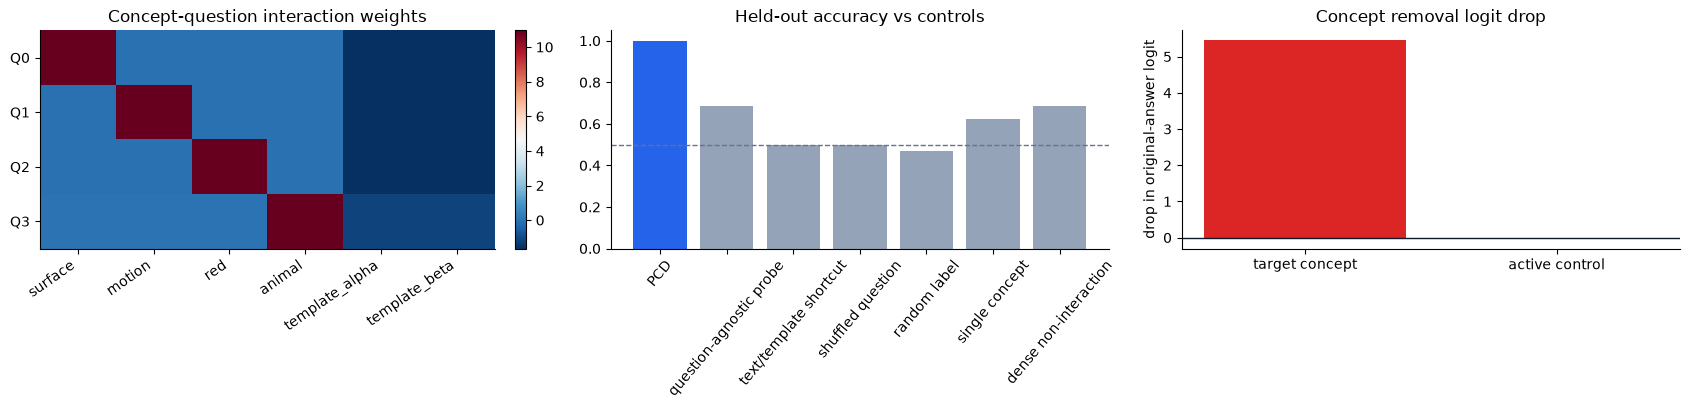

,value
pcd_accuracy,1.0
question_agnostic_probe_accuracy,0.6875
text_template_shortcut_accuracy,0.5
shuffled_question_accuracy,0.5
random_label_accuracy,0.46875
single_concept_accuracy,0.625
dense_noninteraction_accuracy,0.6875
best_control_accuracy,0.6875
pcd_margin_over_best_control,0.3125
passes_controls,True


,prompt,question,answer,pcd_pred,probe_pred,text_template_pred,dense_noninteraction_pred
0,heldout latent card 00 / template 1,Is the hidden surface concept active?,0,0,0,0,0
1,heldout latent card 00 / template 1,Is the hidden motion concept active?,0,0,0,1,0
2,heldout latent card 00 / template 1,Is the hidden red concept active?,0,0,0,0,0
3,heldout latent card 00 / template 1,Is the hidden animal concept active?,0,0,0,0,0
4,heldout latent card 01 / template 2,Is the hidden surface concept active?,0,0,0,1,0
5,heldout latent card 01 / template 2,Is the hidden motion concept active?,0,0,0,1,0
6,heldout latent card 01 / template 2,Is the hidden red concept active?,0,0,0,1,0
7,heldout latent card 01 / template 2,Is the hidden animal concept active?,0,0,0,1,0
8,heldout latent card 02 / template 1,Is the hidden surface concept active?,1,1,0,0,0
9,heldout latent card 02 / template 1,Is the hidden motion concept active?,0,0,0,1,0


In [10]:
planted = run_planted_pcd_experiment(seed=0, steps=350, lr=0.08)
world = planted["world"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

heatmap = planted["heatmap"].detach()
im = axes[0].imshow(heatmap, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Concept-question interaction weights")
axes[0].set_xticks(range(len(world.concept_names)), world.concept_names, rotation=35, ha="right")
axes[0].set_yticks(range(len(world.question_texts)), [f"Q{i}" for i in range(len(world.question_texts))])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

colors = ["#2563eb"] + ["#94a3b8"] * (len(planted["baseline_names"]) - 1)
axes[1].bar(planted["baseline_names"], planted["baseline_accuracies"], color=colors)
axes[1].axhline(0.5, color="#64748b", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Held-out accuracy vs controls")
axes[1].tick_params(axis="x", rotation=50)

removal = planted["removal_report"]
axes[2].bar(
    ["target concept", "active control"],
    [removal.target_logit_delta, removal.active_control_logit_delta],
    color=["#dc2626", "#94a3b8"],
)
axes[2].axhline(0, color="#111827", linewidth=1)
axes[2].set_title("Concept removal logit drop")
axes[2].set_ylabel("drop in original-answer logit")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

summary = planted["baseline_report"].__dict__
display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))
display(pd.DataFrame(planted["prediction_rows"]).head(12))


### Exercise - inspect the real `gelu-1l` evidence honestly

> ```yaml
> Difficulty: medium
> Importance: medium
> You should spend 10 minutes on this exercise.
> ```

The real-model path uses pinned TransformerLens `gelu-1l` final-token residual activations on safe surface-vs-motion prompts. This notebook pass does not run CUDA. It reads the committed verification report and extracts row-level prompt predictions when a fresh GPU report contains them. Older reports only have aggregate metrics; in that case the helper is allowed to infer PCD row correctness only when aggregate `pcd_accuracy == 1.0`, and it marks the source as aggregate-derived.

<details>
<summary>Expected output</summary>

```text
All tests in `test_gelu1l_prompt_prediction_table_uses_direct_rows_or_honest_aggregate` passed!
```

The current report should show `gelu-1l`, `pcd_accuracy=1.0`, baseline accuracies below the PCD, question shuffle failure, stable top concepts, and top-concept removal beating the active control.

</details>

<details>
<summary>Help - why not invent missing row logits?</summary>

If a report only has aggregate metrics, you cannot reconstruct baseline logits or margins for individual rows. The helper may infer that every PCD row is correct only because `pcd_accuracy == 1.0` over the full row count; it must not invent per-row baseline predictions.

</details>

<details>
<summary>Interpretation</summary>

The real evidence is a scoped mechanics preflight. It connects the toy lesson to a trained transformer, but it is not a full PCD paper replication or a downstream model-level causal intervention.

</details>

<details>
<summary>Solution</summary>

```python
def gelu1l_prompt_prediction_table(report: dict) -> list[dict[str, object]]:
    """Extract direct gelu-1l rows when present; otherwise make an honest aggregate table."""

    metrics = report.get("metrics", {}).get("gpu_test", report)
    direct_rows = metrics.get("eval_prediction_rows")
    if direct_rows is not None:
        return list(direct_rows)

    required = {
        "pcd_accuracy",
        "pcd_row_count",
        "eval_example_count",
        "question_count",
        "preflight_passed",
    }
    missing = sorted(key for key in required if key not in metrics)
    if missing:
        raise ValueError(f"report is missing required aggregate fields: {missing}")
    if metrics["eval_example_count"] != len(TL_EVAL_EXAMPLES):
        raise ValueError("aggregate report eval count does not match the pinned prompt list.")
    if metrics["question_count"] != len(TL_PCD_QUESTIONS):
        raise ValueError("aggregate report question count does not match the pinned question bank.")
    if metrics["pcd_row_count"] != len(TL_EVAL_EXAMPLES) * len(TL_PCD_QUESTIONS):
        raise ValueError("aggregate report row count does not match prompts times questions.")
    if metrics["pcd_accuracy"] != 1.0:
        raise ValueError("cannot infer per-row PCD correctness unless aggregate PCD accuracy is 1.0.")

    rows = []
    for prompt_index, (prompt, label) in enumerate(TL_EVAL_EXAMPLES):
        for question_id, question in enumerate(TL_PCD_QUESTIONS):
            answer = int(
                (question_id in (0, 2) and label == "surface")
                or (question_id in (1, 3) and label == "motion")
            )
            rows.append(
                {
                    "prompt": prompt,
                    "latent_label": label,
                    "question": question,
                    "answer": answer,
                    "pcd_pred": answer,
                    "source": "aggregate_report_pcd_accuracy_1.0_no_baseline_row_logits",
                }
            )
    return rows
```

</details>


In [11]:
def gelu1l_prompt_prediction_table(report: dict) -> list[dict[str, object]]:
    """Extract direct gelu-1l rows when present; otherwise make an honest aggregate table."""

    metrics = report.get("metrics", {}).get("gpu_test", report)
    direct_rows = metrics.get("eval_prediction_rows")
    if direct_rows is not None:
        return list(direct_rows)

    required = {
        "pcd_accuracy",
        "pcd_row_count",
        "eval_example_count",
        "question_count",
        "preflight_passed",
    }
    missing = sorted(key for key in required if key not in metrics)
    if missing:
        raise ValueError(f"report is missing required aggregate fields: {missing}")
    if metrics["eval_example_count"] != len(TL_EVAL_EXAMPLES):
        raise ValueError("aggregate report eval count does not match the pinned prompt list.")
    if metrics["question_count"] != len(TL_PCD_QUESTIONS):
        raise ValueError("aggregate report question count does not match the pinned question bank.")
    if metrics["pcd_row_count"] != len(TL_EVAL_EXAMPLES) * len(TL_PCD_QUESTIONS):
        raise ValueError("aggregate report row count does not match prompts times questions.")
    if metrics["pcd_accuracy"] != 1.0:
        raise ValueError("cannot infer per-row PCD correctness unless aggregate PCD accuracy is 1.0.")

    rows = []
    for prompt_index, (prompt, label) in enumerate(TL_EVAL_EXAMPLES):
        for question_id, question in enumerate(TL_PCD_QUESTIONS):
            answer = int(
                (question_id in (0, 2) and label == "surface")
                or (question_id in (1, 3) and label == "motion")
            )
            rows.append(
                {
                    "prompt": prompt,
                    "latent_label": label,
                    "question": question,
                    "answer": answer,
                    "pcd_pred": answer,
                    "source": "aggregate_report_pcd_accuracy_1.0_no_baseline_row_logits",
                }
            )
    return rows


tests.test_gelu1l_prompt_prediction_table_uses_direct_rows_or_honest_aggregate(
    gelu1l_prompt_prediction_table,
)

# After implementing, inspect the current committed report without running GPU.
report = json.loads((section_dir / "verification_report.json").read_text())
gpu = report["metrics"]["gpu_test"]
real_rows = gelu1l_prompt_prediction_table(report)
metric_keys = [
    "model_name",
    "hook_name",
    "pcd_accuracy",
    "probe_accuracy",
    "sae_classifier_accuracy",
    "non_interaction_baseline_accuracy",
    "question_shuffle_accuracy",
    "pcd_seed_min_accuracy",
    "top_removal_changed",
    "random_removal_does_less",
    "peak_vram_gb",
]
display(pd.DataFrame({"metric": metric_keys, "value": [gpu[k] for k in metric_keys]}))
display(pd.DataFrame(real_rows).head(12))


All tests in `test_gelu1l_prompt_prediction_table_uses_direct_rows_or_honest_aggregate` passed!


,metric,value
0,model_name,gelu-1l
1,hook_name,blocks.0.hook_resid_post
2,pcd_accuracy,1.0
3,probe_accuracy,0.5
4,sae_classifier_accuracy,0.5
5,non_interaction_baseline_accuracy,0.5
6,question_shuffle_accuracy,0.0
7,pcd_seed_min_accuracy,1.0
8,top_removal_changed,True
9,random_removal_does_less,True


,answer,dense_noninteraction_pred,latent_label,pcd_pred,probe_pred,prompt,question,single_concept_pred
0,1,0,surface,1,0,"Yesterday at home, the blanket lay on the",Will the next token be the surface-associated ...,0
1,0,0,surface,0,0,"Yesterday at home, the blanket lay on the",Will the next token be the motion-associated t...,0
2,1,0,surface,1,0,"Yesterday at home, the blanket lay on the",Is the hidden state carrying a resting-surface...,0
3,0,0,surface,0,0,"Yesterday at home, the blanket lay on the",Is the hidden state carrying a motion-or-airbo...,0
4,1,0,surface,1,0,"In the quiet room, the lamp sat on the",Will the next token be the surface-associated ...,0
5,0,0,surface,0,0,"In the quiet room, the lamp sat on the",Will the next token be the motion-associated t...,0
6,1,0,surface,1,0,"In the quiet room, the lamp sat on the",Is the hidden state carrying a resting-surface...,0
7,0,0,surface,0,0,"In the quiet room, the lamp sat on the",Is the hidden state carrying a motion-or-airbo...,0
8,1,1,surface,1,0,"After dinner, the pillow rested on the",Will the next token be the surface-associated ...,0
9,0,1,surface,0,0,"After dinner, the pillow rested on the",Will the next token be the motion-associated t...,0


## Combined CPU Contract

This final CPU check composes the learner-facing path. It should include the old helper contracts and the new planted-world signature result. It still does not run CUDA.

<details>
<summary>Expected output</summary>

```text
All tests in `test_notebook_contract` passed!
```

</details>


In [12]:
@dataclass(frozen=True)
class PCDComparisonReport:
    pcd_accuracy: float
    probe_accuracy: float
    sae_classifier_accuracy: float
    activation_oracle_accuracy: float
    best_baseline_accuracy: float
    beats_probe: bool
    beats_best_baseline: bool


@dataclass(frozen=True)
class ConceptStabilityReport:
    top_concepts_by_seed: tuple[tuple[int, ...], ...]
    mean_pairwise_jaccard: float
    stable: bool


@dataclass(frozen=True)
class ConceptRemovalReport:
    original_answer: int
    top_removed_answer: int
    random_removed_answer: int
    top_removal_changed: bool
    random_removal_changed: bool
    top_removal_delta: float
    random_removal_delta: float
    random_removal_does_less: bool


@dataclass(frozen=True)
class ConceptAuditReport:
    selected_concept_ids: tuple[int, ...]
    selected_concept_names: tuple[str, ...]
    explanation: str
    names_expected_cluster: bool


def pcd_comparison_report(
    pcd_logits: t.Tensor,
    probe_logits: t.Tensor,
    sae_classifier_logits: t.Tensor,
    activation_oracle_logits: t.Tensor,
    answer_ids: t.Tensor,
) -> PCDComparisonReport:
    """Compare a PCD against probe, SAE-classifier, and oracle-style baselines."""

    pcd_accuracy = _prediction_accuracy(pcd_logits, answer_ids)
    probe_accuracy = _prediction_accuracy(probe_logits, answer_ids)
    sae_accuracy = _prediction_accuracy(sae_classifier_logits, answer_ids)
    oracle_accuracy = _prediction_accuracy(activation_oracle_logits, answer_ids)
    best_baseline = max(probe_accuracy, sae_accuracy, oracle_accuracy)
    return PCDComparisonReport(
        pcd_accuracy=pcd_accuracy,
        probe_accuracy=probe_accuracy,
        sae_classifier_accuracy=sae_accuracy,
        activation_oracle_accuracy=oracle_accuracy,
        best_baseline_accuracy=best_baseline,
        beats_probe=pcd_accuracy > probe_accuracy,
        beats_best_baseline=pcd_accuracy > best_baseline,
    )


def concept_stability_report(
    concept_scores_by_seed: list[t.Tensor],
    *,
    top_k: int = 3,
    min_jaccard: float = 0.5,
) -> ConceptStabilityReport:
    """Check whether top concepts are stable across random seeds."""

    if len(concept_scores_by_seed) == 0:
        raise ValueError("concept_scores_by_seed must be nonempty.")
    if top_k <= 0:
        raise ValueError("top_k must be positive.")
    if not 0.0 <= min_jaccard <= 1.0:
        raise ValueError("min_jaccard must be between 0 and 1.")

    top_concepts: list[tuple[int, ...]] = []
    for scores in concept_scores_by_seed:
        flat_scores = scores.flatten().float()
        k = min(top_k, flat_scores.numel())
        indices = flat_scores.topk(k=k).indices.tolist()
        top_concepts.append(tuple(int(index) for index in indices))

    overlaps = []
    for i, left in enumerate(top_concepts):
        for right in top_concepts[i + 1 :]:
            left_set = set(left)
            right_set = set(right)
            overlaps.append(len(left_set & right_set) / len(left_set | right_set))
    mean_jaccard = sum(overlaps) / len(overlaps) if overlaps else 1.0
    return ConceptStabilityReport(
        top_concepts_by_seed=tuple(top_concepts),
        mean_pairwise_jaccard=mean_jaccard,
        stable=mean_jaccard >= min_jaccard,
    )


def concept_removal_report(
    original_logits: t.Tensor,
    top_removed_logits: t.Tensor,
    random_removed_logits: t.Tensor,
    *,
    target_answer_id: int | None = None,
) -> ConceptRemovalReport:
    """Check that top removal beats a lower-impact comparison removal."""

    if original_logits.ndim != 1:
        raise ValueError("original_logits must be rank-1.")
    if top_removed_logits.shape != original_logits.shape:
        raise ValueError("top_removed_logits must match original_logits.")
    if random_removed_logits.shape != original_logits.shape:
        raise ValueError("random_removed_logits must match original_logits.")
    if target_answer_id is None:
        target_answer_id = int(original_logits.argmax().item())
    if not 0 <= target_answer_id < original_logits.shape[0]:
        raise ValueError("target_answer_id is out of range.")

    original_answer = int(original_logits.argmax().item())
    top_removed_answer = int(top_removed_logits.argmax().item())
    random_removed_answer = int(random_removed_logits.argmax().item())
    top_delta = original_logits[target_answer_id] - top_removed_logits[target_answer_id]
    random_delta = original_logits[target_answer_id] - random_removed_logits[target_answer_id]
    return ConceptRemovalReport(
        original_answer=original_answer,
        top_removed_answer=top_removed_answer,
        random_removed_answer=random_removed_answer,
        top_removal_changed=original_answer != top_removed_answer,
        random_removal_changed=original_answer != random_removed_answer,
        top_removal_delta=float(top_delta.item()),
        random_removal_delta=float(random_delta.item()),
        random_removal_does_less=abs(random_delta.item()) < abs(top_delta.item()),
    )


def concept_audit_report(
    concept_scores: t.Tensor,
    concept_names: list[str],
    expected_cluster_terms: list[str],
    *,
    top_k: int = 2,
) -> ConceptAuditReport:
    """Select top concepts and check whether their names match an expected cluster."""

    if top_k <= 0:
        raise ValueError("top_k must be positive.")
    if concept_scores.numel() == 0:
        raise ValueError("concept_scores must be nonempty.")
    if concept_scores.numel() != len(concept_names):
        raise ValueError("concept_scores and concept_names must align.")
    if len(expected_cluster_terms) == 0:
        raise ValueError("expected_cluster_terms must be nonempty.")
    flat_scores = concept_scores.flatten().float()
    k = min(top_k, flat_scores.numel())
    selected_ids = tuple(int(index) for index in flat_scores.topk(k=k).indices.tolist())
    selected_names = tuple(concept_names[index] for index in selected_ids)
    normalized_terms = [term.lower() for term in expected_cluster_terms]
    matched = any(
        term in name.lower()
        for name in selected_names
        for term in normalized_terms
    )
    explanation = "Top concepts: " + ", ".join(selected_names)
    return ConceptAuditReport(
        selected_concept_ids=selected_ids,
        selected_concept_names=selected_names,
        explanation=explanation,
        names_expected_cluster=matched,
    )


def batch_smoke_test() -> dict:
    activations = t.eye(4)
    question_ids = t.tensor([0, 1, 2, 3])
    answer_ids = t.tensor([1, 0, 1, 0])
    batch = build_pcd_question_batch(activations, question_ids, answer_ids)
    return {
        "activation_shape": list(batch.activations.shape),
        "num_questions": len(default_pcd_questions()),
        "answer_ids": batch.answer_ids.tolist(),
    }


def sparse_encoding_smoke_test() -> dict:
    activations = t.eye(3)
    concept_directions = t.eye(3)
    concepts = sparse_concept_encode(activations, concept_directions, top_k=1)
    sparsity = concept_sparsity_report(concepts, max_density=0.34)
    return {
        "concepts": concepts.tolist(),
        "sparsity": sparsity.__dict__,
    }


def decoder_smoke_test() -> list[list[float]]:
    concepts = t.tensor([[1.0, 0.0], [0.0, 1.0]])
    question_embeddings = t.tensor([[0.0, 1.0], [1.0, 0.0]])
    decoder_weight = t.tensor(
        [
            [2.0, 0.0],
            [0.0, 2.0],
            [0.0, 1.0],
            [1.0, 0.0],
        ]
    )
    logits = question_conditioned_decoder_logits(
        concepts,
        question_embeddings,
        decoder_weight,
    )
    return logits.tolist()


def decoder_training_smoke_test() -> dict:
    concepts = t.tensor([[2.0, 0.0], [0.0, 2.0]])
    repeated_concepts = concepts.repeat_interleave(2, dim=0)
    question_ids = t.tensor([0, 1, 0, 1])
    question_embeddings = t.eye(2).repeat(2, 1)
    answer_ids = t.tensor([1, 0, 0, 1])
    conditioned = question_conditioned_concept_features(
        repeated_concepts,
        question_ids,
        question_count=2,
    )
    decoder_weight, decoder_bias, report = train_question_conditioned_decoder(
        conditioned,
        question_embeddings,
        answer_ids,
        steps=250,
        lr=0.1,
        seed=0,
    )
    logits = question_conditioned_decoder_logits(
        conditioned,
        question_embeddings,
        decoder_weight,
        decoder_bias=decoder_bias,
    )
    return {
        "conditioned_shape": list(conditioned.shape),
        "train_accuracy": report.train_accuracy,
        "final_loss": report.final_loss,
        "predictions": logits.argmax(dim=-1).tolist(),
        "answer_ids": answer_ids.tolist(),
    }


def comparison_smoke_test() -> dict:
    answer_ids = t.tensor([0, 1, 0, 1])
    pcd_logits = t.tensor([[2.0, 0.0], [0.0, 2.0], [2.0, 0.0], [0.0, 2.0]])
    probe_logits = t.tensor([[2.0, 0.0], [2.0, 0.0], [2.0, 0.0], [2.0, 0.0]])
    sae_logits = probe_logits.clone()
    oracle_logits = t.tensor([[2.0, 0.0], [0.0, 2.0], [2.0, 0.0], [2.0, 0.0]])
    return pcd_comparison_report(
        pcd_logits,
        probe_logits,
        sae_logits,
        oracle_logits,
        answer_ids,
    ).__dict__


def stability_smoke_test() -> dict:
    scores_by_seed = [
        t.tensor([0.9, 0.8, 0.1, 0.0]),
        t.tensor([0.8, 0.7, 0.2, 0.0]),
        t.tensor([0.95, 0.85, 0.05, 0.0]),
    ]
    return concept_stability_report(scores_by_seed, top_k=2, min_jaccard=0.75).__dict__


def removal_smoke_test() -> dict:
    original_logits = t.tensor([3.0, 1.0])
    top_removed_logits = t.tensor([0.0, 2.0])
    random_removed_logits = t.tensor([2.5, 1.0])
    return concept_removal_report(
        original_logits,
        top_removed_logits,
        random_removed_logits,
    ).__dict__


def audit_smoke_test() -> dict:
    concept_scores = t.tensor([0.1, 0.9, 0.8])
    concept_names = ["syntax feature", "refusal feature", "safety refusal"]
    return concept_audit_report(
        concept_scores,
        concept_names,
        ["refusal"],
        top_k=2,
    ).__dict__


def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    planted = run_planted_pcd_experiment(seed=0, steps=350, lr=0.08)
    baseline_report = planted["baseline_report"]
    removal_report = planted["removal_report"]
    return {
        "batch": batch_smoke_test(),
        "sparse_encoding": sparse_encoding_smoke_test(),
        "decoder": decoder_smoke_test(),
        "decoder_training": decoder_training_smoke_test(),
        "comparison": comparison_smoke_test(),
        "stability": stability_smoke_test(),
        "removal": removal_smoke_test(),
        "audit": audit_smoke_test(),
        "planted": {
            "train_examples": len(planted["world"].train_prompts),
            "heldout_examples": len(planted["world"].heldout_prompts),
            "question_count": len(planted["world"].question_texts),
            "concept_names": list(planted["world"].concept_names),
            "train_recovery_error": planted["train_recovery_error"],
            "heldout_recovery_error": planted["heldout_recovery_error"],
            "heatmap_shape": list(planted["heatmap"].shape),
            "heatmap": planted["heatmap"].tolist(),
            "baselines": baseline_report.__dict__,
            "baseline_names": list(planted["baseline_names"]),
            "baseline_accuracies": list(planted["baseline_accuracies"]),
            "removal": removal_report.__dict__,
            "prediction_rows_preview": planted["prediction_rows"][:8],
        },
    }


tests.test_notebook_contract(run_smoke_test)
tests.test_solution_notebook_exposes_taught_implementations()


All tests in `test_notebook_contract` passed!


## Try It Yourself

Change `example_index`, `question_id`, or `target_concept_id`. A useful play cell should make the mechanism feel editable: you can inspect the active concepts, ask a different question, and remove a concept to see whether the answer changes.


In [13]:
# Try changing these.
example_index = 30
question_id = 0
target_concept_id = 0
active_control_concept_id = 1

planted = run_planted_pcd_experiment(seed=0, steps=350, lr=0.08)
world = planted["world"]
row = example_index * len(world.question_texts) + question_id
print("prompt:", world.heldout_prompts[example_index])
print("question:", world.question_texts[question_id])
print("active concepts:", [name for name, value in zip(world.concept_names, planted["heldout_rows"][row]) if value.item() > 0])
print("PCD logits:", planted["pcd_logits"][row].tolist())
print("answer / prediction:", int(planted["heldout_answers"][row].item()), int(planted["pcd_logits"][row].argmax().item()))

removal = targeted_concept_removal_report(
    planted["heldout_rows"],
    planted["heldout_question_ids"],
    planted["heldout_questions"],
    planted["decoder_weight"],
    planted["decoder_bias"],
    prompts=world.heldout_prompts,
    question_texts=world.question_texts,
    concept_names=world.concept_names,
    example_index=example_index,
    question_id=question_id,
    target_concept_id=target_concept_id,
    active_control_concept_id=active_control_concept_id,
)
removal


prompt: heldout latent card 30 / template 1
question: Is the hidden surface concept active?
active concepts: ['surface', 'motion', 'red', 'animal', 'template_beta']
PCD logits: [-2.7294201850891113, 2.6861014366149902]
answer / prediction: 1 1


TargetedConceptRemovalReport(row_index=120, prompt='heldout latent card 30 / template 1', question='Is the hidden surface concept active?', target_concept='surface', active_control_concept='motion', original_answer=1, target_removed_answer=0, active_control_removed_answer=1, target_logit_delta=5.451663970947266, active_control_logit_delta=-0.0273284912109375, target_removal_changed=True, active_control_changed=False, active_control_does_less=True)

## Bonus: Anomaly Hunting

Look for controls that get rows right for the wrong reason. A baseline can fail overall while still matching the PCD on easy rows. Inspect those rows and ask whether the prompt template, nuisance concepts, or class balance accidentally helped it.


In [14]:
planted = run_planted_pcd_experiment(seed=0, steps=350, lr=0.08)
rows = pd.DataFrame(planted["prediction_rows"])
rows["pcd_correct"] = rows["pcd_pred"] == rows["answer"]
rows["probe_correct"] = rows["probe_pred"] == rows["answer"]
rows["text_correct"] = rows["text_template_pred"] == rows["answer"]
rows["dense_correct"] = rows["dense_noninteraction_pred"] == rows["answer"]
interesting = rows[rows["pcd_correct"] & (rows["probe_correct"] | rows["text_correct"] | rows["dense_correct"])]
display(interesting.head(12))
print("Control agreement rates:")
print(rows[["probe_correct", "text_correct", "dense_correct"]].mean())


,prompt,question,answer,pcd_pred,probe_pred,text_template_pred,dense_noninteraction_pred,pcd_correct,probe_correct,text_correct,dense_correct
0,heldout latent card 00 / template 1,Is the hidden surface concept active?,0,0,0,0,0,True,True,True,True
1,heldout latent card 00 / template 1,Is the hidden motion concept active?,0,0,0,1,0,True,True,False,True
2,heldout latent card 00 / template 1,Is the hidden red concept active?,0,0,0,0,0,True,True,True,True
3,heldout latent card 00 / template 1,Is the hidden animal concept active?,0,0,0,0,0,True,True,True,True
4,heldout latent card 01 / template 2,Is the hidden surface concept active?,0,0,0,1,0,True,True,False,True
5,heldout latent card 01 / template 2,Is the hidden motion concept active?,0,0,0,1,0,True,True,False,True
6,heldout latent card 01 / template 2,Is the hidden red concept active?,0,0,0,1,0,True,True,False,True
7,heldout latent card 01 / template 2,Is the hidden animal concept active?,0,0,0,1,0,True,True,False,True
9,heldout latent card 02 / template 1,Is the hidden motion concept active?,0,0,0,1,0,True,True,False,True
10,heldout latent card 02 / template 1,Is the hidden red concept active?,0,0,0,0,0,True,True,True,True


Control agreement rates:
probe_correct    0.6875
text_correct     0.5000
dense_correct    0.6875
dtype: float64


## Limitations and Reading

The toy world is exact by construction; it proves the mechanics and rejects shortcuts under known ground truth. It does not prove that learned concept names in real models are semantic truth.

The `gelu-1l` section is a scoped preflight: final-token residual activations, safe surface-vs-motion prompts, handcrafted sparse concept directions from anchored residual differences plus principal components, a tiny question-conditioned decoder, and decoder-level removal. It does not claim a broad PCD benchmark, a full Activation Oracle comparison, or downstream model-level causal steering.

Read next:

- Predictive Concept Decoders project page and paper for the large-scale method.
- Original ARENA linear probes and activation patching sections for the surrounding methodology.
- Activation Oracles and Natural Language Autoencoders for adjacent activation-to-language approaches.
